### Task 1 - Asset Selection & Data Download
Financial Assets for the portfolio:
- HDFC AMC (Large Cap)
- Macpower CNC (Small Cap)
- NIFTY 50 (Index)
- EUR/INR (FX Rate)
- Gold (Commodity)

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
import seaborn as sns
plt.style.use("default")
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Define tickers
tickers = {
    "HDFC AMC (Large Cap)": "HDFCAMC.NS",
    "Macpower CNC (Small Cap)": "MACPOWER.NS",
    "NIFTY 50 (Index)": "^NSEI",
    "EUR/INR (FX Rate)": "EURINR=X",
    "Gold (Commodity)": "GC=F"
}

# Define date range
start_date = "2019-06-16" # nana's birthday
end_date = "2024-06-26" # dada's birthday

# Download adjusted close prices (USD/INR pulled alongside, just to convert Gold to INR/10g)
raw = yf.download(list(tickers.values()) + ["USDINR=X"], start=start_date, end=end_date, auto_adjust=False)["Adj Close"]
raw = raw[list(tickers.values()) + ["USDINR=X"]]  # force intended column order - yfinance can return multi-ticker columns alphabetically, not in request order
raw.columns = list(tickers.keys()) + ["USD/INR"]

# Gold quoted by yfinance is USD per troy ounce; convert to INR per 10 grams,
# which is how gold is actually quoted in India (1 troy oz = 31.1034768 g)
raw["Gold (Commodity)"] = raw["Gold (Commodity)"] * raw["USD/INR"] / 31.1034768 * 10

data = raw[list(tickers.keys())]
data

[*********************100%***********************]  6 of 6 completed


,HDFC AMC (Large Cap),Macpower CNC (Small Cap),NIFTY 50 (Index),EUR/INR (FX Rate),Gold (Commodity)
Date,,,,,
2019-06-17,845.548889,116.606438,11672.150391,78.195999,30029.364816
2019-06-18,791.904663,117.180389,11691.500000,78.297997,30354.643471
2019-06-19,789.168884,117.180389,11691.450195,77.869003,30159.334623
2019-06-20,797.201172,114.788956,11831.750000,78.175003,31289.726598
2019-06-21,819.547546,128.181000,11724.099609,78.445999,31323.453489
...,...,...,...,...,...
2024-06-19,1873.254761,1381.594604,23516.000000,89.454002,NaN
2024-06-20,1869.364380,1449.147339,23567.000000,89.611000,63536.562848
2024-06-21,1879.258301,1399.180298,23501.099609,89.397003,62659.248225


### Task 2 - Data Cleaning and Preprocessing
- Using Forward Fill (ffill) for missing values
- Calculate log returns
- Visualization using Line Charts and Histograms 

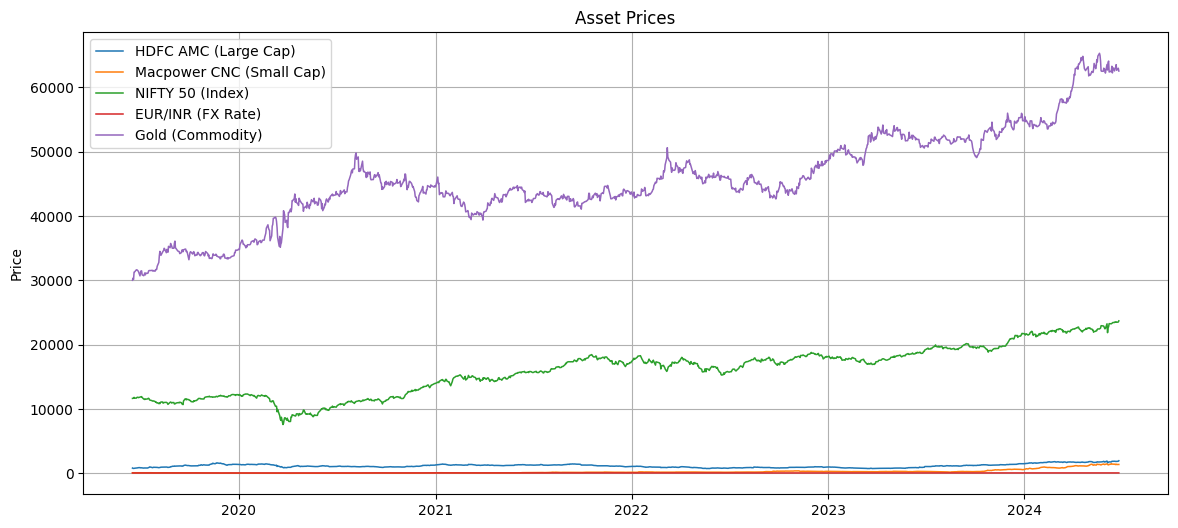

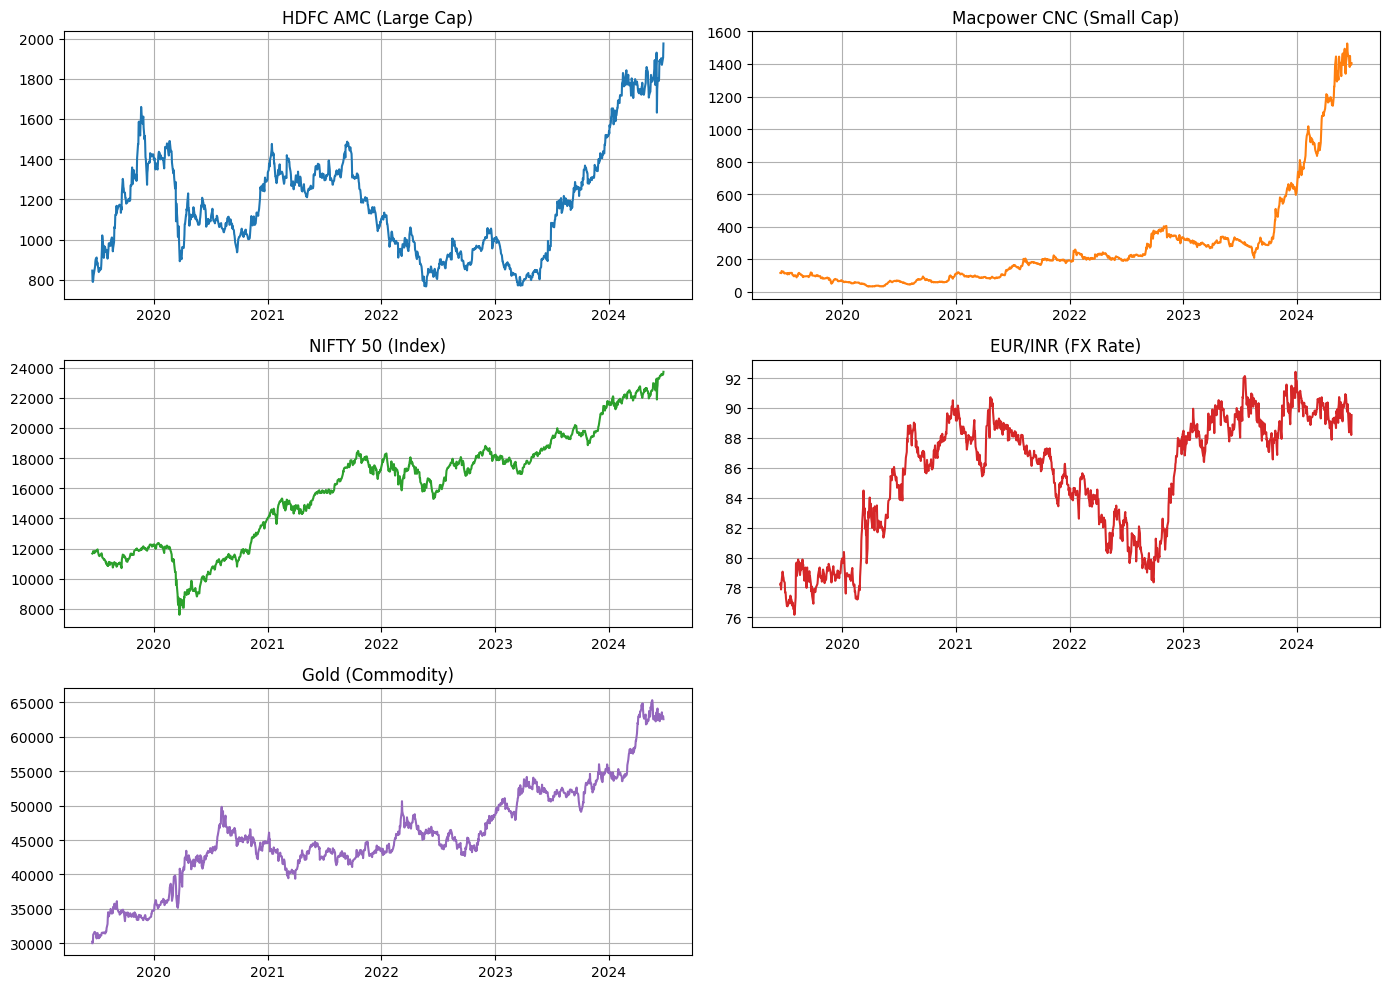

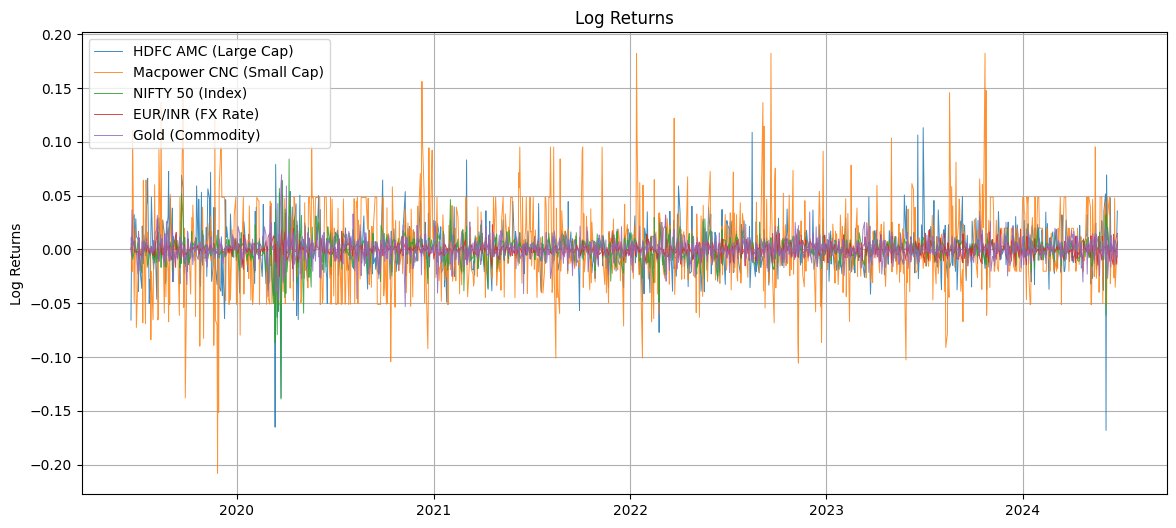

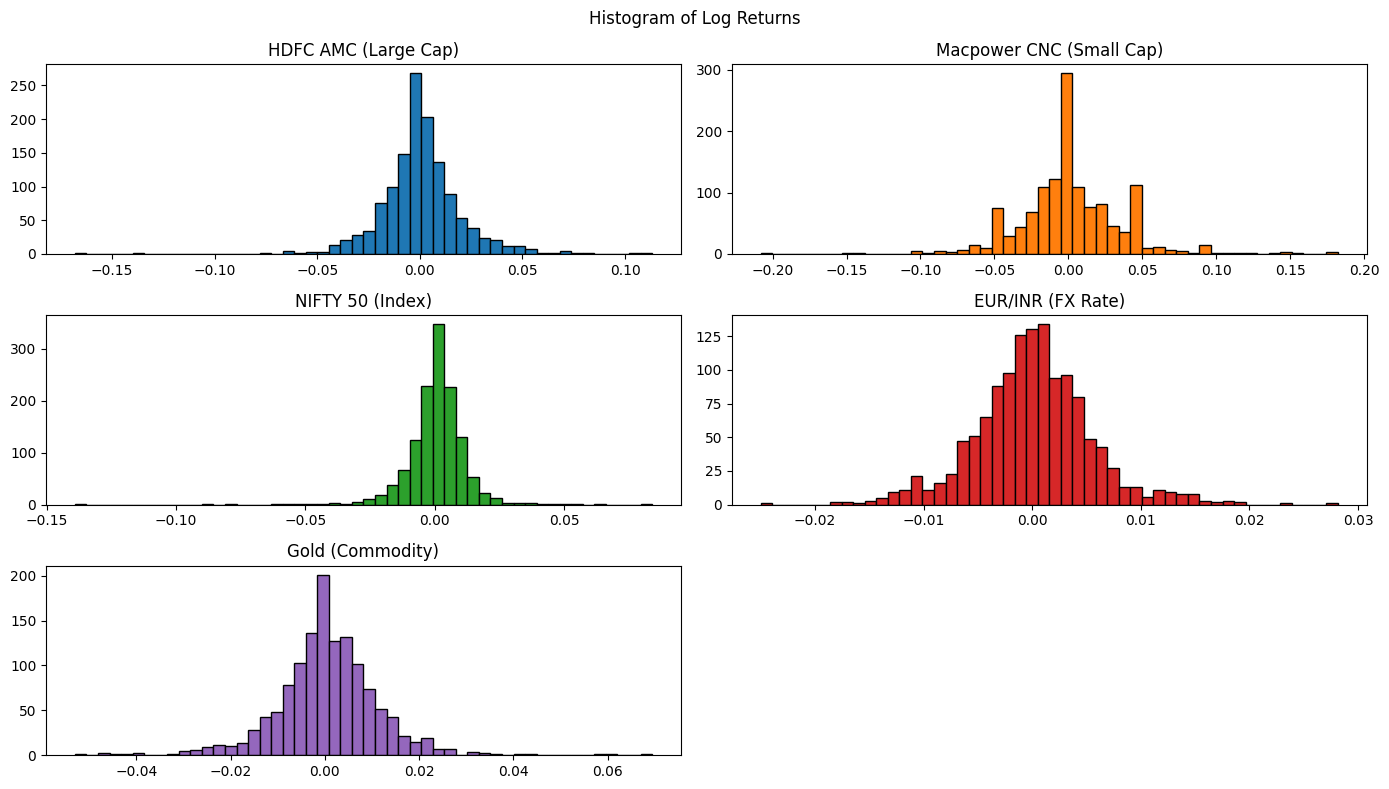

In [3]:
# Forward fill to handle missing values
data_ffill = data.ffill().dropna()

# Calculate daily log returns
returns = np.log(data_ffill / data_ffill.shift(1)).dropna()

# Fixed color per asset, reused across every chart below so the same asset
# always has the same color (tab10 palette - 5 clearly distinguishable colors)
asset_colors = dict(zip(data_ffill.columns, plt.cm.tab10.colors[:len(data_ffill.columns)]))

# Plot price history (raw values, native units)
fig, ax = plt.subplots(figsize=(14, 6))
for col in data_ffill.columns:
    ax.plot(data_ffill.index, data_ffill[col], label=col, color=asset_colors[col], lw=1.1)
ax.set_title("Asset Prices")
ax.set_ylabel("Price")
ax.grid(True)
ax.legend(loc="upper left")
plt.show()

# Extra graph: each asset in its own panel, in native units (NIFTY ~20,000
# points dwarfs EUR/INR ~90 on the combined chart above, so this makes the
# smaller-scale series readable too)
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
for ax, col in zip(axes.ravel(), data_ffill.columns):
    ax.plot(data_ffill.index, data_ffill[col], color=asset_colors[col])
    ax.set_title(col)
    ax.grid(True)
axes.ravel()[-1].axis("off")
plt.tight_layout()
plt.show()

# Plot return history
fig, ax = plt.subplots(figsize=(14, 6))
for col in returns.columns:
    ax.plot(returns.index, returns[col], label=col, color=asset_colors[col], lw=0.7, alpha=0.85)
ax.set_title("Log Returns")
ax.set_ylabel("Log Returns")
ax.grid(True)
ax.legend(loc="upper left")
plt.show()

# Plot histograms of returns
fig, axes = plt.subplots(3, 2, figsize=(14, 8))
for ax, col in zip(axes.ravel(), returns.columns):
    ax.hist(returns[col], bins=50, edgecolor='black', color=asset_colors[col])
    ax.set_title(col)
axes.ravel()[-1].axis("off")
plt.suptitle("Histogram of Log Returns")
plt.tight_layout()
plt.show()

In [4]:
# merge all the returns into a single DataFrame
returns_df = pd.DataFrame(returns)
returns_df.columns = tickers.keys()
from scipy.stats import skew, kurtosis

data = returns_df.reset_index()
data['Date'] = pd.to_datetime(data['Date'])
data

,Date,HDFC AMC (Large Cap),Macpower CNC (Small Cap),NIFTY 50 (Index),EUR/INR (FX Rate),Gold (Commodity)
0,2019-06-18,-0.065545,0.004910,0.001656,0.001304,0.010774
1,2019-06-19,-0.003461,0.000000,-0.000004,-0.005494,-0.006455
2,2019-06-20,0.010127,-0.020619,0.011929,0.003922,0.036795
3,2019-06-21,0.027645,0.110348,-0.009140,0.003461,0.001077
4,2019-06-24,0.032372,-0.049723,-0.002088,0.007771,0.009865
...,...,...,...,...,...,...
1308,2024-06-19,-0.015456,-0.026474,-0.001780,-0.001966,0.000000
1309,2024-06-20,-0.002079,0.047737,0.002166,0.001754,0.008287
1310,2024-06-21,0.005279,-0.035089,-0.002800,-0.002391,-0.013904
1311,2024-06-24,0.014236,-0.002995,0.001563,-0.013577,0.005179


In [5]:
# Task 2 : Printing the summary statistics upto 2 decimal points
for col in returns_df.columns:
    print(f"Summary statistics for {col}:")
    print(f"Mean: {returns_df[col].mean():.5f}")
    print(f"Standard Deviation: {returns_df[col].std():.2f}")
    print(f"Skewness: {skew(returns_df[col]):.2f}")
    print(f"Kurtosis: {kurtosis(returns_df[col]):.2f}")
    print("-" * 50)


Summary statistics for HDFC AMC (Large Cap):
Mean: 0.00065
Standard Deviation: 0.02
Skewness: -0.47
Kurtosis: 10.18
--------------------------------------------------
Summary statistics for Macpower CNC (Small Cap):
Mean: 0.00190
Standard Deviation: 0.04
Skewness: 0.43
Kurtosis: 3.70
--------------------------------------------------
Summary statistics for NIFTY 50 (Index):
Mean: 0.00054
Standard Deviation: 0.01
Skewness: -1.69
Kurtosis: 22.56
--------------------------------------------------
Summary statistics for EUR/INR (FX Rate):
Mean: 0.00010
Standard Deviation: 0.01
Skewness: 0.19
Kurtosis: 1.84
--------------------------------------------------
Summary statistics for Gold (Commodity):
Mean: 0.00056
Standard Deviation: 0.01
Skewness: 0.10
Kurtosis: 4.34
--------------------------------------------------


In [6]:
# Task 3 - Performing Volatility estimation using Historical Volatility Method and GARCH-type models
portfolio_weights = np.array([0.2] * len(returns_df.columns))  # Equal weights for each asset
portfolio_returns = returns_df.dot(portfolio_weights)
portfolio_returns_df = pd.DataFrame(portfolio_returns, columns=["Portfolio Returns"])

# print the mean std skewness and kurtosis of the portfolio returns
print(f"Summary statistics for the portfolio:")
print(f"Mean: {portfolio_returns_df['Portfolio Returns'].mean():.5f}")
print(f"Standard Deviation: {portfolio_returns_df['Portfolio Returns'].std():.5f}")
print(f"Skewness: {skew(portfolio_returns_df['Portfolio Returns']):.2f}")
print(f"Kurtosis: {kurtosis(portfolio_returns_df['Portfolio Returns']):.2f}")
print("-" * 50)

portfolio_returns_df

Summary statistics for the portfolio:
Mean: 0.00075
Standard Deviation: 0.01025
Skewness: -0.46
Kurtosis: 3.99
--------------------------------------------------


,Portfolio Returns
Date,
2019-06-18,-0.009380
2019-06-19,-0.003083
2019-06-20,0.008431
2019-06-21,0.026678
2019-06-24,-0.000361
...,...
2024-06-19,-0.009135
2024-06-20,0.011573
2024-06-21,-0.009781


### Task 3 - Volatility Modeling and Forecasting
- Finding the best ARIMA Model by comparing BIC scores
- Testing for Heteroskedasticity using GARCH models
- Forecasting volatility for 30 days
- Interpretation of the output

Performing stepwise search to minimize bic
 ARIMA(0,0,0)(0,0,0)[0]             : BIC=-8288.486, Time=0.21 sec
 ARIMA(1,0,0)(0,0,0)[0]             : BIC=-8285.863, Time=0.13 sec
 ARIMA(0,0,1)(0,0,0)[0]             : BIC=-8285.428, Time=0.14 sec
 ARIMA(1,0,1)(0,0,0)[0]             : BIC=-8282.914, Time=0.41 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : BIC=-8288.295, Time=0.49 sec

Best model:  ARIMA(0,0,0)(0,0,0)[0]          
Total fit time: 1.540 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1313
Model:                        SARIMAX   Log Likelihood                4147.833
Date:                Sat, 26 Sep 2026   AIC                          -8293.666
Time:                        17:42:31   BIC                          -8288.486
Sample:                             0   HQIC                         -8291.723
                               - 1313                                  

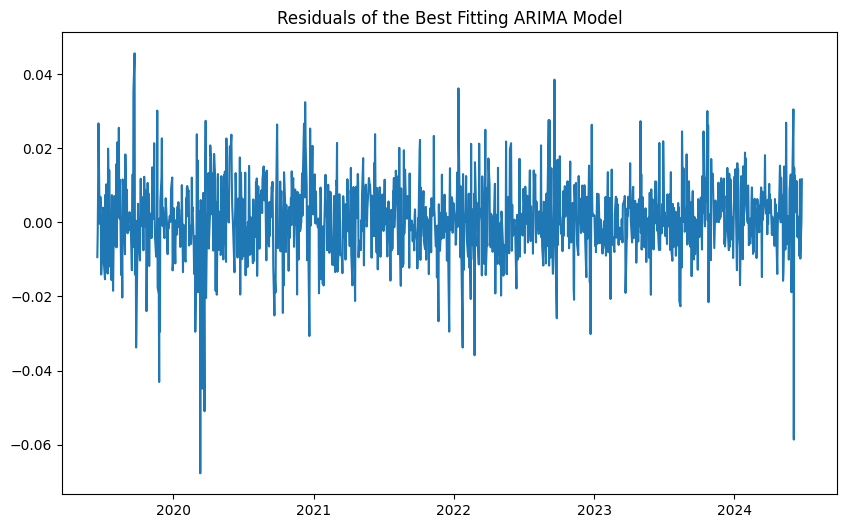

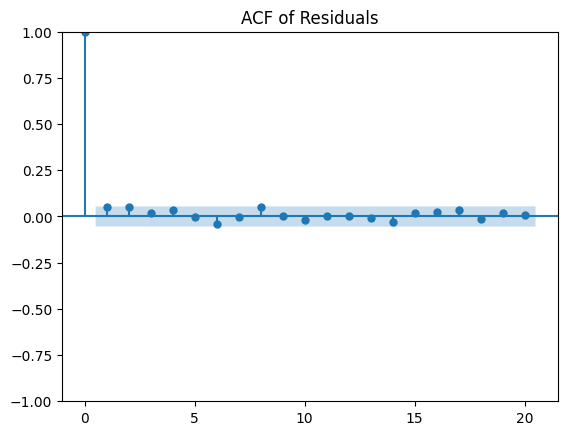

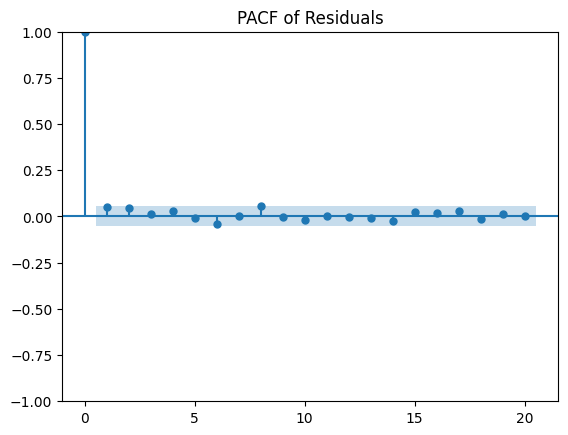

In [7]:
# Modeling the returns using ARIMA 
import pmdarima as pm

# Assuming 'data' and 'returns' are defined from the previous code
returns = portfolio_returns_df['Portfolio Returns'].dropna()

# Find best ARIMA model
# NOTE: information_criterion defaults to 'aic' here (not 'bic').
# BIC's penalty term is log(n) per extra parameter vs AIC's flat 2 per
# parameter, so on a return series with 1000+ observations BIC penalizes
# extra AR/MA terms much more harshly and tends to under-fit the mean
# equation. AIC is the more standard choice for picking a forecasting model.
arima_model = pm.auto_arima(returns, start_p=0, start_q=0,
                           max_p=5, max_q=5, m=1,
                           start_P=0, seasonal=False,
                           d=None, D=0,information_criterion='bic', trace=True,
                           error_action='ignore',  # we don't want to know if an order does not work
                           suppress_warnings=True,  # we don't want convergence warnings
                           stepwise=True)

# Print the model summary
print(arima_model.summary())

# Get the residuals
residuals = arima_model.resid()

# Analyze the residuals (e.g., plot them, check for autocorrelation)
plt.figure(figsize=(10, 6))
plt.plot(residuals)
plt.title("Residuals of the Best Fitting ARIMA Model")
plt.show()

# Further analysis on residuals (e.g., ACF, PACF plots)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(residuals, lags=20)
plt.title("ACF of Residuals")
plt.show()

plot_pacf(residuals, lags=20)
plt.title("PACF of Residuals")
plt.show()

In [8]:
# performing tests for checking for hetersoskedasticity
import statsmodels.api as sm

# Assuming 'residuals' from the ARIMA model is available
# Perform the Breusch-Pagan test for heteroskedasticity
bp_test = sm.stats.diagnostic.het_breuschpagan(residuals, exog_het=sm.add_constant(np.arange(len(residuals))))

# Print the test results
print("\nBreusch-Pagan Test for Heteroskedasticity:")
labels = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']
for label, value in zip(labels, bp_test):
    print(f"{label}: {value}")

# Interpretation
alpha = 0.05  # Significance level
if bp_test[1] < alpha:
    print("Reject the null hypothesis. Heteroskedasticity is present in the residuals.")
else:
    print("Fail to reject the null hypothesis. Heteroskedasticity is not present in the residuals.")


# Alternatively, you can use the Goldfeld-Quandt test
gq_test = sm.stats.diagnostic.het_goldfeldquandt(residuals, x=sm.add_constant(np.arange(len(residuals))))

print("\nGoldfeld-Quandt Test for Heteroskedasticity:")
print(f"F-statistic: {gq_test[0]}")
print(f"p-value: {gq_test[1]}")

if gq_test[1] < alpha:
  print("Reject the null hypothesis. Heteroskedasticity is present in the residuals.")
else:
  print("Fail to reject the null hypothesis. Heteroskedasticity is not present in the residuals.")


Breusch-Pagan Test for Heteroskedasticity:
Lagrange multiplier statistic: 10.322886714431439
p-value: 0.0013139061926728658
f-value: 10.388840292500728
f p-value: 0.0012989968234852958
Reject the null hypothesis. Heteroskedasticity is present in the residuals.

Goldfeld-Quandt Test for Heteroskedasticity:
F-statistic: 0.7440587639333107
p-value: 0.9999194146639006
Fail to reject the null hypothesis. Heteroskedasticity is not present in the residuals.


In [9]:
# Assuming 'residuals' from the ARIMA model is available
# Perform the ARCH test for conditional heteroskedasticity
arch_test = sm.stats.diagnostic.acorr_ljungbox(residuals**2, lags=[10], return_df=True) # Test on squared residuals

# Print the test results
print("\nARCH Test for Conditional Heteroskedasticity (Ljung-Box test on squared residuals):")
print(arch_test)

# Interpretation
alpha = 0.05  # Significance level
if arch_test['lb_pvalue'][10] < alpha:
    print("Reject the null hypothesis. Conditional heteroskedasticity is present in the residuals.")
else:
    print("Fail to reject the null hypothesis. Conditional heteroskedasticity is not present in the residuals.")


ARCH Test for Conditional Heteroskedasticity (Ljung-Box test on squared residuals):
       lb_stat     lb_pvalue
10  145.035058  3.907332e-26
Reject the null hypothesis. Conditional heteroskedasticity is present in the residuals.


- According to the Breusch-Pagan test and ARCH Test (Ljung-Box), conditional heteroskedasticity is present in the time-series
-This leads to modelling of volatility

In [10]:
import arch

# Assuming 'residuals' from the ARIMA model is available
# Fit different GARCH models
garch_models = {
    'Standard GARCH': arch.arch_model(residuals, vol='Garch', p=1, q=1),
    'EGARCH': arch.arch_model(residuals, vol='EGARCH', p=1, o=1, q=1),
    'GJR-GARCH': arch.arch_model(residuals, vol='GARCH', p=1, o=1, q=1),  # GJR is a special case of GARCH
    'APARCH': arch.arch_model(residuals, vol='APARCH', p=1, o=1, q=1),
    'FIGARCH': arch.arch_model(residuals, vol='FIGARCH', p=1, o=1, q=1)
}

results = {}
for name, model in garch_models.items():
    try:
        results[name] = model.fit(disp='off')  # Fit the model (suppress output)
        print(f"Successfully fit {name}")
    except Exception as e:
        print(f"Error fitting {name}: {e}")

# Compare AIC/BIC to find the best fitting model
best_model_name = None
best_aic = float('inf')
best_bic = float('inf')

for name, result in results.items():
    if result.aic < best_aic:
        best_aic = result.aic
        best_model_name = name
    if result.bic < best_bic:
        best_bic = result.bic
for name, result in results.items():
    print(f"{name}: AIC = {result.aic:.2f}, BIC = {result.bic:.2f}")
print(f"Best Model (by AIC): {best_model_name}")


# Get residuals from the best GARCH model
if best_model_name in results:
    best_model_result = results[best_model_name]
    best_garch_residuals = best_model_result.std_resid
else:
    print("Best model not found in results!")
    best_garch_residuals = None

egarch_params=results['EGARCH'].params
print(egarch_params)
    
# print(results)

Successfully fit Standard GARCH
Successfully fit EGARCH
Successfully fit GJR-GARCH
Successfully fit APARCH
Successfully fit FIGARCH
Standard GARCH: AIC = -8407.46, BIC = -8386.74
EGARCH: AIC = -8403.90, BIC = -8378.00
GJR-GARCH: AIC = -8405.87, BIC = -8379.97
APARCH: AIC = -8406.99, BIC = -8375.91
FIGARCH: AIC = -8398.28, BIC = -8372.38
Best Model (by AIC): Standard GARCH
mu          0.000747
omega      -1.132057
alpha[1]    0.258466
gamma[1]   -0.020398
beta[1]     0.876075
Name: params, dtype: float64


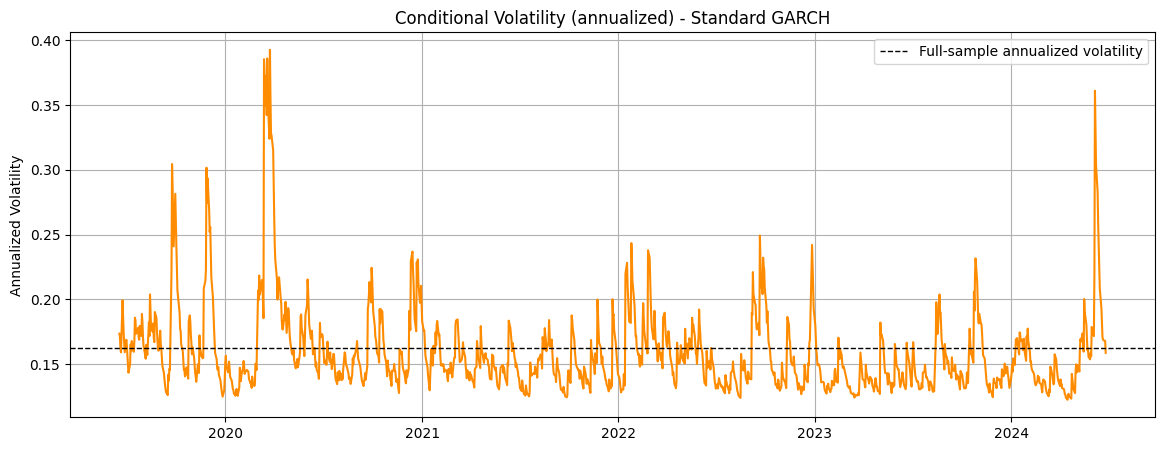

In [11]:
# Extra graph - annualized conditional volatility from the best-fit GARCH model
cond_vol_annual = best_model_result.conditional_volatility * np.sqrt(252)
plt.figure(figsize=(14, 5))
plt.plot(cond_vol_annual.index, cond_vol_annual, color='darkorange')
plt.axhline(portfolio_returns_df['Portfolio Returns'].std() * np.sqrt(252),
            color='black', linestyle='--', lw=1, label='Full-sample annualized volatility')
plt.title(f"Conditional Volatility (annualized) - {best_model_name}")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.grid(True)
plt.show()

In [12]:
# We simulate as follows for each day, define r_t=sigma_t X z_t , now sample 1000 z's to get 1000 returns
# now std dev of this 1000 observations is essentially vol/sqrt(252) and thus it yileds vol1, do these 30 times
forecast_horizon = 30
num_simulations = 1000

# 1) Run a simulation‑based forecast
fc = best_model_result.forecast(
    horizon=forecast_horizon,
    method='simulation',
    simulations=num_simulations
)

# fc.simulations is an (horizon × simulations) array of returns
simulated_returns = fc.simulations.values*np.sqrt(252)
# for daily volatility, we simply use the fc.simulations.values  

# 2) Compute daily vol as the std‑dev across the simulation axis
volatility_forecast = simulated_returns.std(axis=1)
volatility_forecast = volatility_forecast.ravel()

# 3) Put into a DataFrame for easy viewing
volatility_forecast_df = pd.DataFrame({
    "Day": np.arange(1, forecast_horizon + 1),
    "Volatility Forecast": volatility_forecast
})

print("\nAnnual volatility Forecast for the Next 30 Days:")
volatility_forecast_df.set_index("Day", inplace=True)
volatility_forecast_df


Annual volatility Forecast for the Next 30 Days:


,Volatility Forecast
Day,
1,0.154872
2,0.158623
3,0.162725
4,0.157167
5,0.160290
6,0.160018
7,0.157182
8,0.158660
9,0.161598


### Task 4 : Value at Risk (VaR) Estimation
- 1-day and 10-day VaR estimation using all 3 methods
- Interpretations and Assumptions

In [13]:
VaR_results = pd.DataFrame(columns=["Simulation Method","VaR_95_1_day", "VaR_99_1_day", "VaR_95_10_day", "VaR_99_10_day"])

In [14]:
# Task 4 - VaR Estimation using 3 methods


# HISTORICAL SIMULATION METHOD
def compute_var_bootstrap(returns, confidence_level, num_simulations=1000):
    var_values = []
    for _ in range(num_simulations):
        # Perform bootstrapping by resampling returns with replacement
        bootstrapped_returns = np.random.choice(returns, size=len(returns), replace=True)

        # Sort the bootstrapped returns
        sorted_returns = np.sort(bootstrapped_returns)

        # Calculate the index corresponding to the desired quantile
        index = int(len(sorted_returns) * (1 - confidence_level))

        # Extract the VaR at the specified confidence level
        var = -sorted_returns[index]
        var_values.append(var)

    # Calculate the mean VaR and the 95% confidence interval
    mean_var = np.mean(var_values)
    lower_bound = np.percentile(var_values, 2.5)
    upper_bound = np.percentile(var_values, 97.5)

    return mean_var, lower_bound, upper_bound

# Compute VaR at 95% and 99% confidence levels
var_95_mean, var_95_lower, var_95_upper = compute_var_bootstrap(returns, 0.95)
var_99_mean, var_99_lower, var_99_upper = compute_var_bootstrap(returns, 0.99)


print(f"95% VaR (Mean) - (one-day) - Historical Simulation: {var_95_mean:.4f}")
print(f"95% VaR (Mean) - (ten-day) - Historical Simulation: {var_95_mean*np.sqrt(10):.4f}")
# print(f"95% VaR Confidence Interval: ({var_95_lower:.4f}, {var_95_upper:.4f})")
print(f"99% VaR (Mean) - (one-day) - Historical Simulation: {var_99_mean:.4f}")
print(f"95% VaR (Mean) - (ten-day) - Historical Simulation: {var_99_mean*np.sqrt(10):.4f}")
# print(f"99% VaR Confidence Interval: ({var_99_lower:.4f}, {var_99_upper:.4f})")
VaR_results = pd.concat([VaR_results, pd.DataFrame([{"Simulation Method": "Historical Simulation", "VaR_95_1_day": var_95_mean, "VaR_99_1_day": var_99_mean,"VaR_95_10_day": var_95_mean*np.sqrt(10), "VaR_99_10_day": var_99_mean*np.sqrt(10)}])], ignore_index=True)


95% VaR (Mean) - (one-day) - Historical Simulation: 0.0145
95% VaR (Mean) - (ten-day) - Historical Simulation: 0.0459
99% VaR (Mean) - (one-day) - Historical Simulation: 0.0278
95% VaR (Mean) - (ten-day) - Historical Simulation: 0.0878


In [15]:
# USING VARIANCE-COVARIANCE VAR METHOD

from scipy import stats

def parametric_var(returns, confidence_level, lookback_period=252):
    """
    Computes Parametric Value at Risk (VaR) using the variance-covariance method.

    Args:
        returns (pd.Series): A pandas Series of historical returns.
        confidence_level (float): The desired confidence level for VaR (e.g., 0.95 for 95% VaR).
        lookback_period (int): The number of past returns to use for estimation.

    Returns:
        float: The calculated VaR value.
    """
    # Calculate the mean and standard deviation of returns over the lookback period.
    mean_return = returns.tail(lookback_period).mean()
    std_dev_return = returns.tail(lookback_period).std()

    # Calculate the z-score corresponding to the confidence level.
    z_score = np.abs(stats.norm.ppf(1 - confidence_level))

    # Calculate VaR using the formula: VaR = mean_return - z_score * std_dev_return
    var = -(mean_return - z_score * std_dev_return)

    return var

# Example usage with your existing returns data:
# Assuming 'returns' is a pandas Series of your daily returns
confidence_level = 0.95  # 95% confidence level
var_95 = parametric_var(returns, confidence_level)
print(f"{confidence_level*100:.0f}% Parametric VaR (one-day): {var_95:.4f}")
print(f"{confidence_level*100:.0f}% Parametric VaR (ten-day): {var_95*np.sqrt(10):.4f}")
# For 99% confidence level
confidence_level = 0.99
var_99 = parametric_var(returns, confidence_level)
print(f"{confidence_level*100:.0f}% Parametric VaR (one-day): {var_99:.4f}")
print(f"{confidence_level*100:.0f}% Parametric VaR (teb-day): {var_99*np.sqrt(10):.4f}")
VaR_results = pd.concat([VaR_results, pd.DataFrame([{"Simulation Method": "Parametric VaR", "VaR_95_1_day": var_95, "VaR_99_1_day": var_99,"VaR_95_10_day": var_95*np.sqrt(10), "VaR_99_10_day": var_99*np.sqrt(10)}])], ignore_index=True)

95% Parametric VaR (one-day): 0.0137
95% Parametric VaR (ten-day): 0.0432
99% Parametric VaR (one-day): 0.0202
99% Parametric VaR (teb-day): 0.0638


In [16]:
# MONTE - CARLO SIMULATIONS METHOD
# lookback period is 252 (1 year) since Basel Comimittee finacnial frameworks explicitly reuqire banks to compute parametric VaR
# using 1 year lookback period,ie, its a industry standard

# find the best fitting distribution
import scipy.stats as st
from scipy.stats import genextreme as gev, genpareto as gpd

def fit_distributions(returns, distributions):
    results = {}
    for distribution_name in distributions:
        try:
            distribution = getattr(st, distribution_name)
            params = distribution.fit(returns)
            results[distribution_name] = {
                'distribution': distribution,
                'params': params,
                'AIC': distribution.nnlf(params, returns) + 2 * len(params),  # AIC
                'BIC': distribution.nnlf(params, returns) + len(params) * np.log(len(returns))  # BIC
            }
        except Exception as e:
            print(f"Error fitting {distribution_name}: {e}")
            continue

    return results

def compare_distributions(results):
    best_distribution = None
    best_aic = float('inf')
    best_bic = float('inf')  # Initialize best_bic to infinity
    for name, result in results.items():
        if result['AIC'] < best_aic:
            best_aic = result['AIC']
            best_distribution = name
        if result['BIC'] < best_bic:  # Compare BIC as well
            best_bic = result['BIC']

    print(f"\nComparison of Distribution Fits:")
    for name, result in results.items():
        print(f"{name}: AIC = {result['AIC']:.2f}, BIC = {result['BIC']:.2f}")  # Print both AIC and BIC
    print(f"Best Distribution by AIC: {best_distribution}")  # Explicitly print by AIC

    # Return AIC and BIC of the best distribution for clarity
    return best_distribution, results[best_distribution]['AIC'], results[best_distribution]['BIC']

# Step 2: Define Distributions to Fit
distributions = [
    'norm', 't', 'cauchy', 'laplace', 'logistic',
    'gumbel_r', 'gumbel_l', 'hypsecant', 'gennorm', 'skewnorm',
    'johnsonsu', 'johnsonsb'
]
distributions.extend(['genextreme', 'genpareto'])  # Add GEV and GPD

# Fit distributions
fitted_distributions = fit_distributions(returns, distributions)
best_dist, best_aic, best_bic = compare_distributions(fitted_distributions)

print(f"\nBest Distribution (AIC): {best_dist}, AIC={best_aic:.2f}, BIC={best_bic:.2f}") # Displaying the best distribution


Comparison of Distribution Fits:
norm: AIC = -4147.33, BIC = -4136.97
t: AIC = -4217.38, BIC = -4201.84
cauchy: AIC = -4079.11, BIC = -4068.75
laplace: AIC = -4211.49, BIC = -4201.13
logistic: AIC = -4210.28, BIC = -4199.92
gumbel_r: AIC = -3773.98, BIC = -3763.62
gumbel_l: AIC = -4009.38, BIC = -3999.02
hypsecant: AIC = -4216.93, BIC = -4206.57
gennorm: AIC = -4213.56, BIC = -4198.02
skewnorm: AIC = -4155.11, BIC = -4139.57
johnsonsu: AIC = -4215.40, BIC = -4194.68
johnsonsb: AIC = -4149.80, BIC = -4129.08
genextreme: AIC = -2322.82, BIC = -2307.28
genpareto: AIC = -2853.70, BIC = -2838.16
Best Distribution by AIC: t

Best Distribution (AIC): t, AIC=-4217.38, BIC=-4201.84


In [17]:
import numpy as np
from scipy.stats import t

def monte_carlo_var(returns, confidence_level, num_simulations=10000, best_dist='t', dist_params=None):
    if best_dist == 't':
        if dist_params is None:
            raise ValueError("Distribution parameters are required for t-distribution")
        df, loc, scale = dist_params  # Extract t-distribution parameters
        simulated_returns = t.rvs(df, loc=loc, scale=scale, size=num_simulations)
    else:
        raise ValueError("Unsupported distribution")

    var = -np.percentile(simulated_returns, 100 * (1 - confidence_level))
    return var

# Example: Access parameters for the t-distribution (replace 't' with your best_dist if different)
if 't' in fitted_distributions:
  t_params = fitted_distributions['t']['params']
  var_95 = monte_carlo_var(returns, 0.95, best_dist='t', dist_params=t_params)
  var_99 = monte_carlo_var(returns, 0.99, best_dist='t', dist_params=t_params)
  print(f"95% VaR (Monte Carlo, t-distribution): {var_95:.4f}")
  print(f"95% VaR (Monte Carlo, t-distribution): {var_95*np.sqrt(10):.4f}")
  print(f"95% VaR (Monte Carlo, t-distribution): {var_99:.4f}")
  print(f"99% VaR (Monte Carlo, t-distribution): {var_99*np.sqrt(10):.4f}")
else:
  print("t distribution not found in fitted distributions")

VaR_results = pd.concat([VaR_results, pd.DataFrame([{"Simulation Method": "Monte-Carlo Simulation", "VaR_95_1_day": var_95, "VaR_99_1_day": var_99,"VaR_95_10_day": var_95*np.sqrt(10), "VaR_99_10_day": var_99*np.sqrt(10)}])], ignore_index=True)


95% VaR (Monte Carlo, t-distribution): 0.0150
95% VaR (Monte Carlo, t-distribution): 0.0474
95% VaR (Monte Carlo, t-distribution): 0.0276
99% VaR (Monte Carlo, t-distribution): 0.0874


In [18]:
VaR_results

,Simulation Method,VaR_95_1_day,VaR_99_1_day,VaR_95_10_day,VaR_99_10_day
0,Historical Simulation,0.014526,0.027756,0.045937,0.087772
1,Parametric VaR,0.013676,0.020175,0.043248,0.063798
2,Monte-Carlo Simulation,0.014989,0.027639,0.0474,0.087404


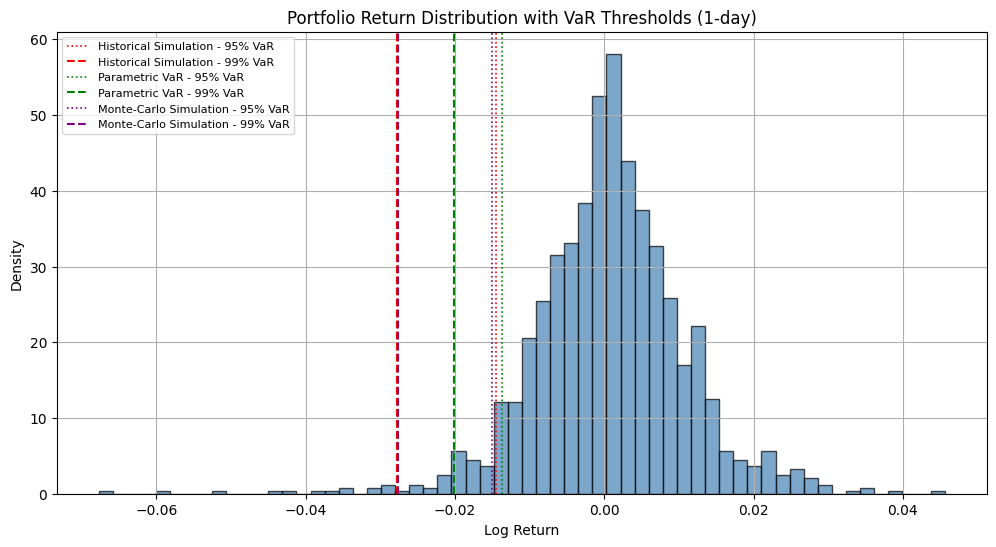

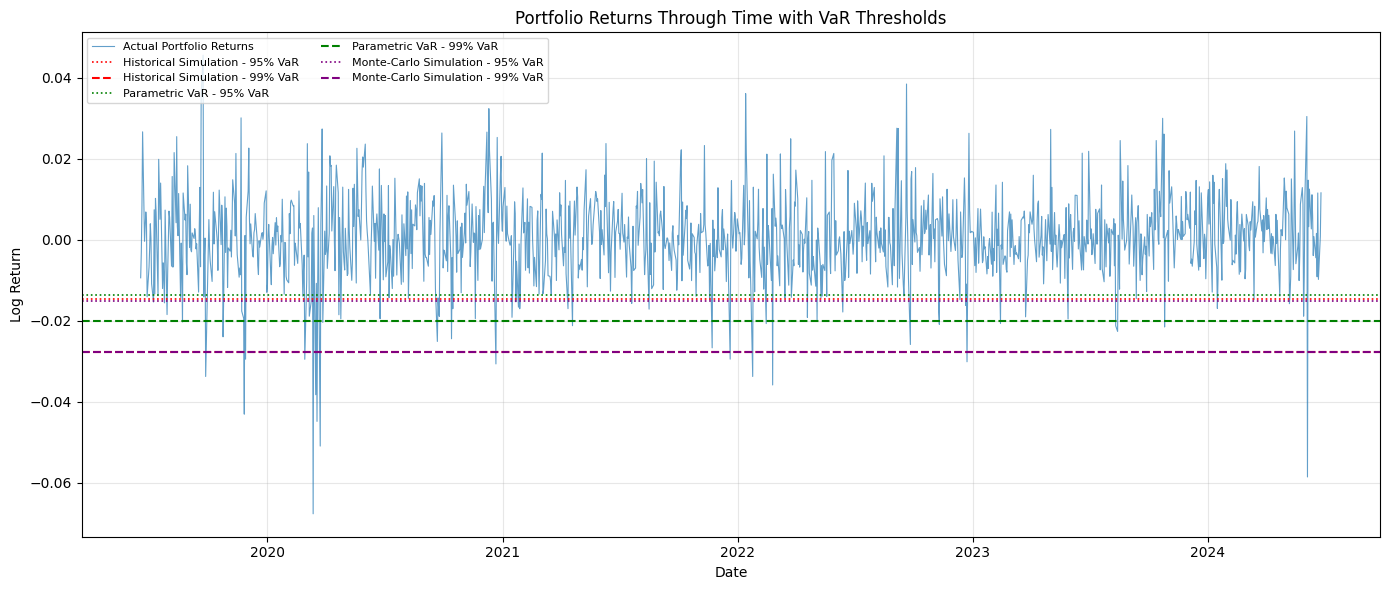

<Figure size 640x480 with 0 Axes>

In [19]:
# Extra graph - portfolio return histogram with the 95%/99% VaR thresholds overlaid
plt.figure(figsize=(12, 6))
plt.hist(returns, bins=60, color='steelblue', edgecolor='black', alpha=0.7, density=True)

colors = {'Historical Simulation': 'red', 'Parametric VaR': 'green', 'Monte-Carlo Simulation': 'purple'}
for _, row in VaR_results.iterrows():
    c = colors.get(row['Simulation Method'], 'black')
    plt.axvline(-row['VaR_95_1_day'], color=c, linestyle=':', lw=1.2,
                label=f"{row['Simulation Method']} - 95% VaR")
    plt.axvline(-row['VaR_99_1_day'], color=c, linestyle='--', lw=1.5,
                label=f"{row['Simulation Method']} - 99% VaR")

plt.title("Portfolio Return Distribution with VaR Thresholds (1-day)")
plt.xlabel("Log Return")
plt.ylabel("Density")
plt.legend(fontsize=8, ncol=1, loc='upper left')
plt.grid(True)

# Portfolio returns through time with VaR thresholds

plt.figure(figsize=(14, 6))

# Actual historical returns
plt.plot(
    returns.index,
    returns.values,
    linewidth=0.8,
    alpha=0.7,
    label='Actual Portfolio Returns'
)

colors = {
    'Historical Simulation': 'red',
    'Parametric VaR': 'green',
    'Monte-Carlo Simulation': 'purple'
}

for _, row in VaR_results.iterrows():
    c = colors.get(row['Simulation Method'], 'black')

    # 95% VaR
    plt.axhline(
        -row['VaR_95_1_day'],
        color=c,
        linestyle=':',
        lw=1.2,
        label=f"{row['Simulation Method']} - 95% VaR"
    )

    # 99% VaR
    plt.axhline(
        -row['VaR_99_1_day'],
        color=c,
        linestyle='--',
        lw=1.5,
        label=f"{row['Simulation Method']} - 99% VaR"
    )

plt.title("Portfolio Returns Through Time with VaR Thresholds")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.legend(fontsize=8, ncol=2, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.tight_layout()
plt.show()

#### The above results indicate the following : 
- 99% VaR > 95% always for the same method since it gives a more risk-sensitive estimate
- Parametric VaR method underpredicts the 1-day and 10-day VaR values since Normal Distribution is not the best fit
- Hisstorical simulation gives VaR estimates that are close to the Monte-Carlo approach, but overpredict the 99% VaR 

### Task 5 - Backtesting and Model Validation

In [20]:
import numpy as np
from scipy.stats import t, norm, chi2
from statsmodels.stats.diagnostic import acorr_ljungbox

# ---------------------------------------------------------------------------
# Backtesting = checking whether the number (and pattern) of VaR breaches in
# the historical data is what the model itself would predict. If a 99% VaR is
# correctly specified, roughly 1% of days should breach it - not more, not
# fewer, and the breaches shouldn't cluster together in time.
# Three checks below do that:
#   1) Kupiec test        -> is the TOTAL number of breaches close to what's
#                             expected (e.g. ~1% of days for a 99% VaR)?
#   2) Christoffersen test -> are the breaches INDEPENDENT over time, or do
#                             they cluster (which would mean the model is slow
#                             to react to changing volatility)?
#   3) Joint test          -> combines both checks into a single conditional-
#                             coverage test (correct rate AND independent).
# ---------------------------------------------------------------------------

def kupiec_test(violations: int, total_obs: int, p_exceed: float) -> float:
    """
    Kupiec POF test (proportion of failures).

    violations   = number of observed exceptions (x)
    total_obs    = number of VaR forecasts (T)
    p_exceed     = expected exception probability (e.g. 0.05 for 95% VaR)

    Returns the p‑value of LR = -2[ log L0 – log L1 ] ~ χ²(1).
    """
    x, T = violations, total_obs
    # avoid log(0) by handling edge cases
    term1 = x * np.log(p_exceed / (x / T))             if x > 0 else 0
    term2 = (T - x) * np.log((1 - p_exceed) / ((T - x) / T)) if T - x > 0 else 0
    LR = -2 * (term1 + term2)
    p_value = 1 - chi2.cdf(LR, df=1)
    return round(p_value, 5)


def christoffersen_test(actual_violations, alpha=0.05):
    """
    Christoffersen test for VaR model accuracy.  Checks for independence of violations.

    Args:
        actual_violations: A series of 1s (violations) and 0s (no violations)
        alpha: Significance level.

    Returns:
        p_value: p-value of the test.
    """
    # Calculate the number of violations
    num_violations = actual_violations.sum()

    # Perform Ljung-Box test on indicator series
    test_result = acorr_ljungbox(actual_violations, lags=1, return_df=True)  # Lag of 1 is sufficient for this test
    p_value = test_result['lb_pvalue'][1]
    return p_value


def christoffersen_joint_test(violations, p=0.01, alpha=0.05):
    """
    Christoffersen (1998) Conditional Coverage Backtest
    violations: pd.Series or np.array of 0s and 1s
    p: expected failure rate (e.g., 0.01 for 99% VaR)
    """
    v = np.asarray(violations)
    N = len(v)

    # --- 1. Unconditional Coverage (Kupiec LR_uc) ---
    # Same idea as kupiec_test() above, just re-derived here via likelihood ratio
    # so it can be summed with the independence LR below into one joint stat.
    x = v.sum() # Total violations
    # Likelihood under null hypothesis
    L_null = (p ** x) * ((1 - p) ** (N - x))
    # Likelihood under alternative
    p_hat = x / N
    L_alt = (p_hat ** x) * ((1 - p_hat) ** (N - x))

    LR_uc = -2 * np.log(L_null / L_alt) if L_alt > 0 else 0
    p_val_uc = 1 - stats.chi2.cdf(LR_uc, df=1)

    # --- 2. Independence Test (Christoffersen LR_ind) ---
    # Count how often a violation is immediately followed by another violation
    # (n01, n11) vs. how often it isn't (n00, n10) - clustering shows up as
    # pi_1 (P[violation | yesterday was a violation]) being much bigger than
    # pi_0 (P[violation | yesterday was fine]).
    n00 = np.sum((v[:-1] == 0) & (v[1:] == 0))
    n01 = np.sum((v[:-1] == 0) & (v[1:] == 1))
    n10 = np.sum((v[:-1] == 1) & (v[1:] == 0))
    n11 = np.sum((v[:-1] == 1) & (v[1:] == 1))

    pi_0 = n01 / (n00 + n01) if (n00 + n01) > 0 else 0
    pi_1 = n11 / (n10 + n11) if (n10 + n11) > 0 else 0
    pi_2 = (n01 + n11) / (n00 + n01 + n10 + n11)

    L_ind_null = ((1 - pi_2)**(n00 + n10)) * (pi_2**(n01 + n11))
    L_ind_alt = ((1 - pi_0)**n00) * (pi_0**n01) * ((1 - pi_1)**n10) * (pi_1**n11)

    LR_ind = -2 * np.log(L_ind_null / L_ind_alt) if L_ind_alt > 0 else 0
    p_val_ind = 1 - stats.chi2.cdf(LR_ind, df=1)

    # --- 3. Combined Conditional Coverage (LR_cc) ---
    # LR_uc and LR_ind are both chi-square(1); their sum is chi-square(2), so
    # this jointly tests "correct violation rate" AND "violations independent".
    LR_cc = LR_uc + LR_ind
    p_val_cc = 1 - stats.chi2.cdf(LR_cc, df=2)

    return {
        "LR_uc (Kupiec)": [LR_uc, p_val_uc],
        "LR_ind (Independence)": [LR_ind, p_val_ind],
        "LR_cc (Joint)": [LR_cc, p_val_cc]
    }

In [21]:
# calculate the number of violations 
# print the acceptable number of violations according to var_95 and var_99
print(f"Acceptable number of violations for 95% VaR: {len(portfolio_returns_df) * 0.05:.2f}")
print(f"Acceptable number of violations for 99% VaR: {len(portfolio_returns_df) * 0.01:.2f}")
violations = (portfolio_returns_df['Portfolio Returns'] < -var_99).astype(int)  # Assuming var_99 is the VaR threshold
violations_ind = violations.astype(int)  # Convert violations to integers for statistical tests
print('Total number of violations:', violations.sum()) 

# Kupiec POF test
p_val_k = kupiec_test(violations.sum(), len(violations), 0.05)
print(f"Kupiec Test p‑value: {p_val_k}")
if(p_val_k < 0.05):
    print("Reject the null hypothesis. Too many violations. The model understates/overstates risk.")
else:
    print("Fail to reject the null hypothesis. Actual number of violations is consistent with expected VaR model.")
# Christoffersen test
p_val_c = christoffersen_test(violations_ind)
print(f"Christoffersen Test p-value: {p_val_c.round(5)}")
if(p_val_c < 0.05):
    print("Reject the null hypothesis. The violations are not independent.")
else:
    print("Fail to reject the null hypothesis. The violations are independent.")


p_val_cc=christoffersen_joint_test(violations, p=0.01, alpha=0.05)["LR_cc (Joint)"][1]
print(f"Christofferesen_joint Test p-value: {p_val_cc.round(5)}")
if(p_val_cc<0.05):
    print("Reject Null Hypothesis,i.e.,violations are not independent or risk under/overstated")
else:
    print("H0 true! ie Model is legally correct and passes all regulations!")

Acceptable number of violations for 95% VaR: 65.65
Acceptable number of violations for 99% VaR: 13.13
Total number of violations: 14
Kupiec Test p‑value: 0.0
Reject the null hypothesis. Too many violations. The model understates/overstates risk.
Christoffersen Test p-value: 0.6956
Fail to reject the null hypothesis. The violations are independent.
Christofferesen_joint Test p-value: 0.83569
H0 true! ie Model is legally correct and passes all regulations!


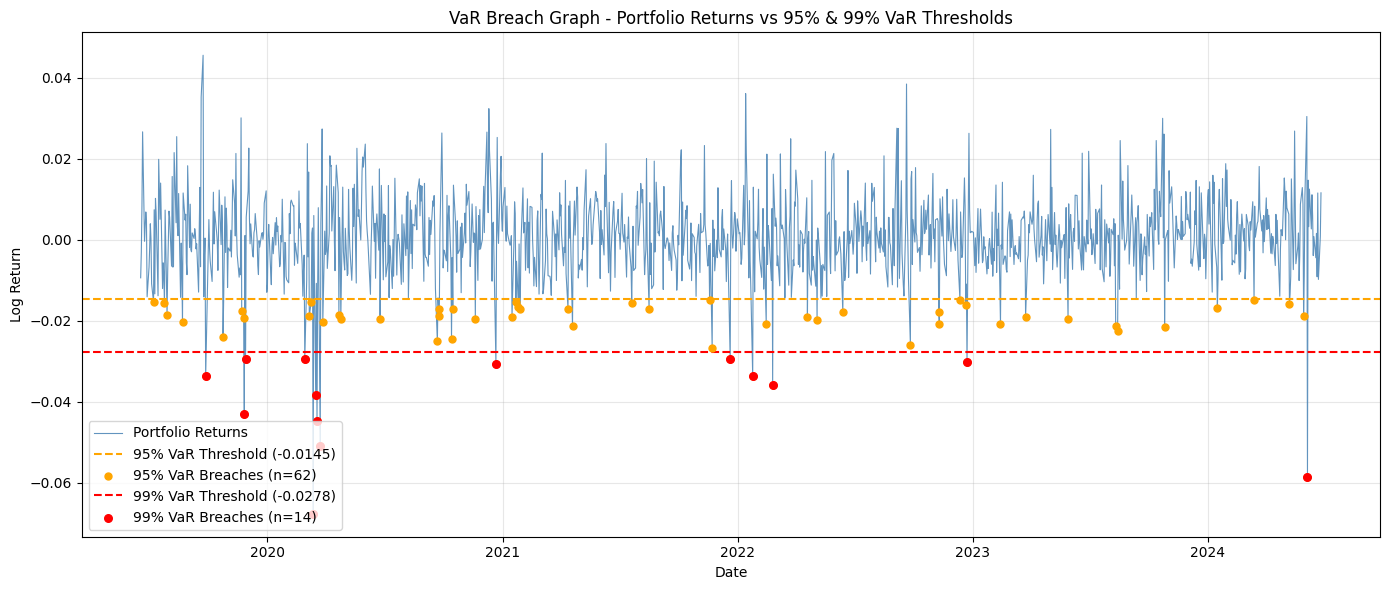

Total 95% VaR Breaches: 62 out of 1313 days
Expected 95% Breaches: 65
----------------------------------------
Total 99% VaR Breaches: 14 out of 1313 days
Expected 99% Breaches: 13


In [22]:
# 1. Calculate Thresholds and Identify Breaches
var_95_threshold = -var_95_mean 
breaches_95 = portfolio_returns_df[portfolio_returns_df['Portfolio Returns'] < var_95_threshold]

var_99_threshold = -var_99_mean
breaches_99 = portfolio_returns_df[portfolio_returns_df['Portfolio Returns'] < var_99_threshold]

# 2. Plotting Both 95% and 99% on the Same Chart
plt.figure(figsize=(14, 6))
plt.plot(portfolio_returns_df.index, portfolio_returns_df['Portfolio Returns'], 
         label='Portfolio Returns', color='steelblue', lw=0.8, alpha=0.85)

# Plot 95% Line & Scatter
plt.axhline(y=var_95_threshold, color='orange', linestyle='--', lw=1.5, 
            label=f'95% VaR Threshold ({var_95_threshold:.4f})')
plt.scatter(breaches_95.index, breaches_95['Portfolio Returns'], 
            color='orange', s=25, zorder=4, 
            label=f'95% VaR Breaches (n={len(breaches_95)})')

# Plot 99% Line & Scatter
plt.axhline(y=var_99_threshold, color='red', linestyle='--', lw=1.5, 
            label=f'99% VaR Threshold ({var_99_threshold:.4f})')
plt.scatter(breaches_99.index, breaches_99['Portfolio Returns'], 
            color='red', s=30, zorder=5, 
            label=f'99% VaR Breaches (n={len(breaches_99)})')

# Formatting
plt.title('VaR Breach Graph - Portfolio Returns vs 95% & 99% VaR Thresholds')
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Print Summary Stats
print(f"Total 95% VaR Breaches: {len(breaches_95)} out of {len(portfolio_returns_df)} days")
print(f"Expected 95% Breaches: {int(len(portfolio_returns_df) * 0.05)}")
print("-" * 40)
print(f"Total 99% VaR Breaches: {len(breaches_99)} out of {len(portfolio_returns_df)} days")
print(f"Expected 99% Breaches: {int(len(portfolio_returns_df) * 0.01)}")

### Task 6 : (Option Pricing and Greek Sensitivities)
#### - Simulated the GBM Stock Prices for SBIN.NS (10,000 simulations) 
#### - Used GBM paths to compute Call/Put option prices
#### - Estimate Delta (finite differences), Gamma, Vega, Theta
#### - Compare the greeks for different strike prices (K) and Maturities (T)


In [23]:
import yfinance as yf
import numpy as np
import pandas as pd
# Task 6 - Option Pricing & Greek Sensitivities
ticker = 'SBIN.NS'  
# simulate GBM paths for
start_date = '2025-01-16' #Maa's Birhtday
end_date = '2025-01-25' #Harsh's Birthday
# use these paths to compute European call/put option prices and Greeks
data = yf.download(ticker, start=start_date, end=end_date, auto_adjust=False)["Adj Close"]
data = data.ffill().dropna()
data = data.reset_index()
data['Date'] = pd.to_datetime(data['Date'])
data

[*********************100%***********************]  1 of 1 completed


Ticker,Date,SBIN.NS
0,2025-01-16,737.914917
1,2025-01-17,735.796387
2,2025-01-20,750.385254
3,2025-01-21,730.933472
4,2025-01-22,725.540955
5,2025-01-23,718.270630
6,2025-01-24,716.585449


In [24]:
import random
import math
def simulate_gbm(S0, mu, sigma, T, N):
    dt = T / N  # Time step
    prices = [S0]  # List to store the stock prices, starting with the initial price
    for i in range(1, N):
        Z = random.gauss(0, 1)  # Generate a random number from a standard normal distribution
        price = prices[i-1] * math.exp((mu - 0.5 * sigma**2) * dt + sigma * math.sqrt(dt) * Z)
        prices.append(price)
    return prices

# Function to simulate multiple paths
def simulate_multiple_paths(S0, mu, sigma, T, N, M):
    all_prices = []  # List to store multiple simulated paths
    for i in range(M):
        all_prices.append(simulate_gbm(S0, mu, sigma, T, N))  # Simulate each path
    return all_prices

# Function to visualize the simulated stock price paths
def plot_simulation_paths(all_prices):
    plt.figure(figsize=(10, 6))
    for path in all_prices:
        plt.plot(path, color='blue', alpha=0.1)  # Simulate multiple paths
    plt.title('SIMULATED GBM PATHS FOR SBI')
    plt.xlabel('Time Steps')
    plt.ylabel('Stock Price')
    plt.show()

In [25]:
# Fetch price specifically around January 16, 2025
sbi_jan16 = yf.download('SBIN.NS', start='2025-01-16', end='2025-01-17', auto_adjust=False)["Close"]
S0 = float(sbi_jan16.iloc[0].item())
print(f"S0 price on 16-01-2025: {S0:.2f}")

# Fetch a trailing 1-year window (ending just before 16-01-2025) to estimate the
# annualized drift (mu) and volatility (sigma) used by the GBM simulation & Greeks below.
# (A single day of data has no return series, which is why mu/sigma came out as NaN/undefined before.)
hist_start = '2024-01-16'
hist_end   = '2025-01-16'
sbi_hist = yf.download('SBIN.NS', start=hist_start, end=hist_end, auto_adjust=False)["Close"]
stock_data = sbi_hist
returns = np.log(stock_data / stock_data.shift(1)).dropna()

mean_returns_sbi = float(returns.mean().item()) * 252
mean_std_sbi = float(returns.std().item()) * np.sqrt(252)

mu = mean_returns_sbi       # annualized drift
sigma = mean_std_sbi        # annualized volatility

print("Mean Returns (mu) : ", mu)
print("Standard Deviation (sigma) : ", sigma)
print("S0 (16-01-2025 price) : ", S0)


[*********************100%***********************]  1 of 1 completed


S0 price on 16-01-2025: 766.30


[*********************100%***********************]  1 of 1 completed

Mean Returns (mu) :  0.17319263794518802
Standard Deviation (sigma) :  0.3004423039586378
S0 (16-01-2025 price) :  766.2999877929688


In [26]:

# GBM path simulator for stock
def simulate_gbm_paths(S0, mu, sigma, T, N, M, seed=None):
    """
    Simulate M GBM paths, each with N time-steps, over total horizon T (in years).
    Returns an (M, N+1) array of prices including S0 at t=0.
    """
    dt = T / N
    if seed is not None:
        np.random.seed(seed)
    # Standard normals: shape (M, N)
    Z = np.random.normal(size=(M, N))
    # Pre-allocate and set initial prices
    S = np.zeros((M, N+1))
    S[:, 0] = S0
    # Step forward
    for t in range(1, N+1):
        S[:, t] = S[:, t-1] * np.exp((mu - 0.5*sigma**2)*dt
                                       + sigma * np.sqrt(dt) * Z[:, t-1])
    return S
# Finding option prices
def price_european_call(S_paths, K, r, T):
    payoffs = np.maximum(S_paths[:, -1] - K, 0)
    return np.exp(-r * T) * np.mean(payoffs)
def price_european_put(S_paths, K, r, T):
    payoffs = np.maximum(K-S_paths[:,-1],0)
    return np.exp(-r * T) * np.mean(payoffs)
# Option Greeks
def delta_fd(base_price_fn, bump):
    C0_call, _ = base_price_fn()
    C_plus_call, _ = base_price_fn(S0_bump=+bump)
    return (C_plus_call - C0_call) / bump

def gamma_fd(base_price_fn, bump):
    C_minus,_ = base_price_fn(S0_bump=-bump)
    C0_call,_      = base_price_fn()
    C_plus,_  = base_price_fn(S0_bump=+bump)
    return (C_plus - 2*C0_call + C_minus) / bump**2

def vega_fd(base_price_fn, bump):
    C_plus,_  = base_price_fn(sigma_bump=+bump)
    C_minus,_ = base_price_fn(sigma_bump=-bump)
    return (C_plus - C_minus) / (2*bump)

def theta_fd(base_price_fn, dt):
    # Theta ≈ (C(T - dt) - C(T)) / dt
    C_now,_    = base_price_fn()
    C_earlier,_ = base_price_fn(T_bump=-dt)
    return (C_earlier - C_now) / dt

def make_pricer(S0, mu, sigma, r, K, T, N, M, seed=42):
    # NOTE: option pricing/Greeks must be done under the RISK-NEUTRAL measure,
    # i.e. the simulated paths used to price the option drift at the risk-free
    # rate r, not at the real-world drift mu (mu is kept as an argument only
    # for interface compatibility with callers - it is intentionally unused
    # for pricing). The *realized* market path used elsewhere for the actual
    # stock-price evolution / delta-hedging P&L is still simulated under the
    # real-world drift mu - which is the standard, correct split: hedge
    # ratios come from risk-neutral pricing, but the world you are hedging
    # against moves under the real-world measure.
    def pricer(S0_bump=0.0, sigma_bump=0.0, T_bump=0.0):
        # adjust parameters
        S0_adj   = S0   + S0_bump
        sigma_adj= sigma+ sigma_bump
        T_adj    = T    + T_bump
        # If T changes, adjust N accordingly so dt=1/252
        N_adj    = int(np.round(T_adj * 252))
        paths = simulate_gbm_paths(S0_adj, r, sigma_adj, T_adj, N_adj, M, seed)  # drift = r (risk-neutral)
        return price_european_call(paths, K, r, T_adj), price_european_put(paths, K, r, T_adj)
    return pricer

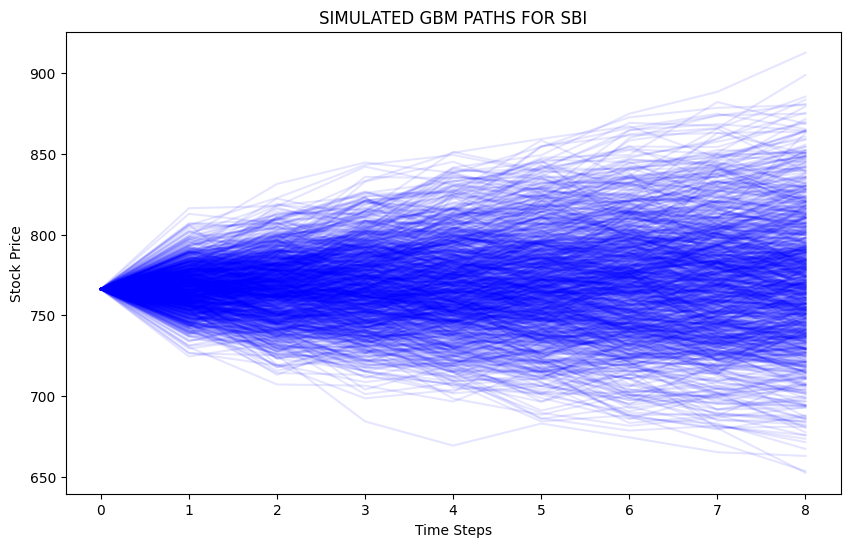

In [27]:
if __name__ == "__main__":

    # Convert parameters to scalar floats
    S0_val = float(S0.item()) if hasattr(S0, 'item') else float(S0)
    mu_val = float(mu.item()) if hasattr(mu, 'item') else float(mu)
    sigma_val = float(sigma.item()) if hasattr(sigma, 'item') else float(sigma)

    r = 0.06              # annual risk-free rate
    # 9 trading days from 16 Jan to 25 Jan => T_full = 9/252
    N_full = 9
    T_full = N_full / 252
    M = 1000               # number of paths

    # Run simulation with float scalars
    simulated_paths = simulate_multiple_paths(S0_val, mu_val, sigma_val, T_full, N_full, M)
    plot_simulation_paths(simulated_paths)

    # Strikes: 90%, 100%, 110% (for comparison across different strike prices)
    strikes = [0.9*S0, S0, 1.1*S0]

    # Maturities (for comparison across different maturities)
    maturity_steps = [N_full//3, 2*(N_full//3), N_full]
    maturities     = [n/252 for n in maturity_steps]

    seed = 42   # for reproducibility

    # Collect results
    results = []

    for T, step in zip(maturities, maturity_steps):
        N = step
        dt = 1/252
        for K in strikes:
            # Create a pricer closure for this (K, T)
            pricer = make_pricer(S0, mu_val, sigma_val, r, K, T, N, M, seed)

            # Base price
            C0_call, C0_put = pricer()

            # Greeks
            dS    = S0 * 1e-2     # 1% bump
            dsig  = sigma * 1e-2  # 1% vol bump
            Δ     = delta_fd(pricer, dS)
            Γ     = gamma_fd(pricer, dS)
            Vega  = vega_fd(pricer, dsig)
            Θ     = theta_fd(pricer, dt)

            results.append({
                'Maturity (days)':   N,
                'Strike':            K,
                'Price (Call)':             C0_call,
                'Price (Put)':              C0_put,
                'Delta':             Δ,
                'Gamma':             Γ,
                'Vega':              Vega,
                'Theta':             Θ,
            })


In [28]:
# Print a summary table
print("\n Option Prices and Greeks:")
print(f"\n Strike Prices used = {[round(k, 2) for k in strikes]}")
print(f"\n Maturity Days = {maturity_steps}")
df = pd.DataFrame(results)
df


 Option Prices and Greeks:

 Strike Prices used = [689.67, 766.3, 842.93]

 Maturity Days = [3, 6, 9]


,Maturity (days),Strike,Price (Call),Price (Put),Delta,Gamma,Vega,Theta
0,3,689.669989,78.496376,0.000000,1.001793,4.840080e-16,4.512709,-59.224320
1,3,766.299988,10.803682,8.882589,0.592763,1.683595e-02,35.061062,-459.928038
2,3,842.929987,0.020351,74.674541,0.004575,3.066779e-04,0.601930,-5.128528
3,6,689.669989,77.403757,0.104948,0.991531,3.845832e-04,1.584731,133.895248
4,6,766.299988,14.110840,13.332637,0.549313,1.143263e-02,45.113486,-130.315738
5,6,842.929987,0.297515,76.039917,0.026250,1.326800e-03,5.721734,-55.903850
6,9,689.669989,78.418983,0.422481,0.977197,1.281029e-03,8.909748,-181.336371
7,9,766.299988,18.274136,16.743603,0.559693,8.981660e-03,58.080573,-516.562288
8,9,842.929987,1.191383,76.126816,0.065973,2.038593e-03,17.103104,-135.699386


### Task 7 : Portfolio 1 (SBI Stock) vs Portfolio 2 (Delta-Hedged Stock + Option) vs Risk-Free Rate

Start with ₹25,000 of capital (change `INITIAL_CAPITAL` below to rescale everything) and compare two ways to
put it to work in SBI over the next year:

- **Portfolio 1 - SBI Stock**: buy ₹25,000 worth of SBIN.NS shares and hold for 1 year.
- **Portfolio 2 - SBI Stock + Option (delta-hedged)**: buy as many 1-year at-the-money SBI **call options** as
  ₹25,000 will buy, and **short Δ = ∂V/∂S shares of SBI stock against them**, so the combined position
  is delta-neutral. Δ is recomputed and the stock leg re-traded **once per trading day** (continuous rebalancing
  isn't achievable in practice, so - as before - we approximate it discretely, at the close).

This is exactly the Black-Scholes hedging argument: a properly delta-hedged position should earn (very close to)
the **risk-free rate**, regardless of which way the stock actually moves, because first-order stock risk has been
cancelled out. Portfolio 1, by contrast, is fully exposed to SBI and should earn its real-world expected return
μ - with a lot more risk along the way.

We simulate `M_paths` independent possible futures for SBI over the next year (real-world drift μ, volatility
σ - same estimates used throughout Task 6/7), run both portfolios down every path, and plot:
- the **expected value** of each portfolio over time (average across simulated futures), with a **green line**
  for the risk-free benchmark, ₹25,000 × e^{rt}
- the **5th-95th percentile spread** of outcomes around each expected line, to show *risk*, not just the average
- the **distribution of year-end values**, to compare the risk of the two portfolios side by side

Note: this needs a fresh delta computed *every day, for every simulated path, for a full year* - re-using Task 6's
nested Monte-Carlo Greeks here would be far too slow. Under the same GBM / risk-neutral assumptions Task 6 already
uses, that Monte-Carlo price/delta converges to the closed-form **Black-Scholes** price/delta - so that's what's
used below, purely for speed. It's the same model, solved analytically instead of by simulation.


In [29]:
# ============================================================
# Task 7 : Portfolio 1 (Stock) vs Portfolio 2 (Delta-Hedged Option) vs Risk-Free
# ============================================================
from scipy.stats import norm

INITIAL_CAPITAL = 25000.0   # <- change this to rescale everything
N_days = 252                 # 1 trading year
dt = 1 / 252
M_paths = 2000                # number of simulated future SBI price paths
K = S0                         # at-the-money call, struck at today's SBI price

def bs_call_price(S, K, T, r, sigma):
    """Black-Scholes call price. S may be a scalar or a numpy array (vectorized over simulated paths)."""
    T = np.maximum(T, 1e-8)
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def bs_call_delta(S, K, T, r, sigma):
    """Black-Scholes call delta = dC/dS."""
    T = np.maximum(T, 1e-8)
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    return norm.cdf(d1)

print(f"Initial capital        : ₹{INITIAL_CAPITAL:,.0f}")
print(f"SBI spot (S0)           : ₹{S0:,.2f}")
print(f"Strike (K, ATM)         : ₹{K:,.2f}")
print(f"Real-world drift (mu)   : {mu_val:.2%}")
print(f"Volatility (sigma)      : {sigma_val:.2%}")
print(f"Risk-free rate (r)      : {r:.2%}")


Initial capital        : ₹25,000
SBI spot (S0)           : ₹766.30
Strike (K, ATM)         : ₹766.30
Real-world drift (mu)   : 17.32%
Volatility (sigma)      : 30.04%
Risk-free rate (r)      : 6.00%


In [30]:
# ---- simulate SBI's next year, and run both portfolios down every simulated path ----
S_sim = simulate_gbm_paths(S0, mu_val, sigma_val, 1.0, N_days, M_paths, seed=42)   # shape (M_paths, N_days+1)

# Portfolio 1 : plain buy-and-hold stock
shares_1 = INITIAL_CAPITAL / S0
value_1 = shares_1 * S_sim                                              # (M_paths, N_days+1)

# Portfolio 2 : long Q call options, short delta*Q shares, rebalanced daily
C0 = bs_call_price(S0, K, 1.0, r, sigma_val)
delta0 = bs_call_delta(S0, K, 1.0, r, sigma_val)
Q = INITIAL_CAPITAL / C0                            # number of call "units" 25,000 buys today

h = np.full(M_paths, -Q * delta0)                                     # short stock leg (negative = short)
cash = np.full(M_paths, INITIAL_CAPITAL - Q * C0 + Q * delta0 * S0)     # spend on calls, receive short-sale proceeds
value_2 = np.zeros((M_paths, N_days + 1))
value_2[:, 0] = Q * C0 + h * S0 + cash                                  # should equal INITIAL_CAPITAL exactly

for t in range(1, N_days + 1):
    cash *= np.exp(r * dt)                            # cash/bond leg accrues overnight
    S_t = S_sim[:, t]
    tau = 1.0 - t / 252                                # remaining time to maturity

    if t < N_days:
        delta_t = bs_call_delta(S_t, K, tau, r, sigma_val)
        h_new = -Q * delta_t
        cash -= (h_new - h) * S_t                      # fund today's rebalancing trade
        h = h_new
        price_t = bs_call_price(S_t, K, tau, r, sigma_val)
    else:
        price_t = np.maximum(S_t - K, 0.0)               # option expires, settle at intrinsic value

    value_2[:, t] = Q * price_t + h * S_t + cash

print(f"Q  (call units bought)      : {Q:.2f}")
print(f"delta_0 (initial delta)     : {delta0:.4f}")
print(f"Initial short-stock leg     : {-h[0]:.2f} shares (₹{-h[0]*S0:,.0f})")
print(f"Portfolio 2 initial value   : ₹{value_2[0,0]:,.2f}  (should equal INITIAL_CAPITAL)")


Q  (call units bought)      : 221.43
delta_0 (initial delta)     : 0.6368
Initial short-stock leg     : 221.43 shares (₹169,679)
Portfolio 2 initial value   : ₹25,000.00  (should equal INITIAL_CAPITAL)


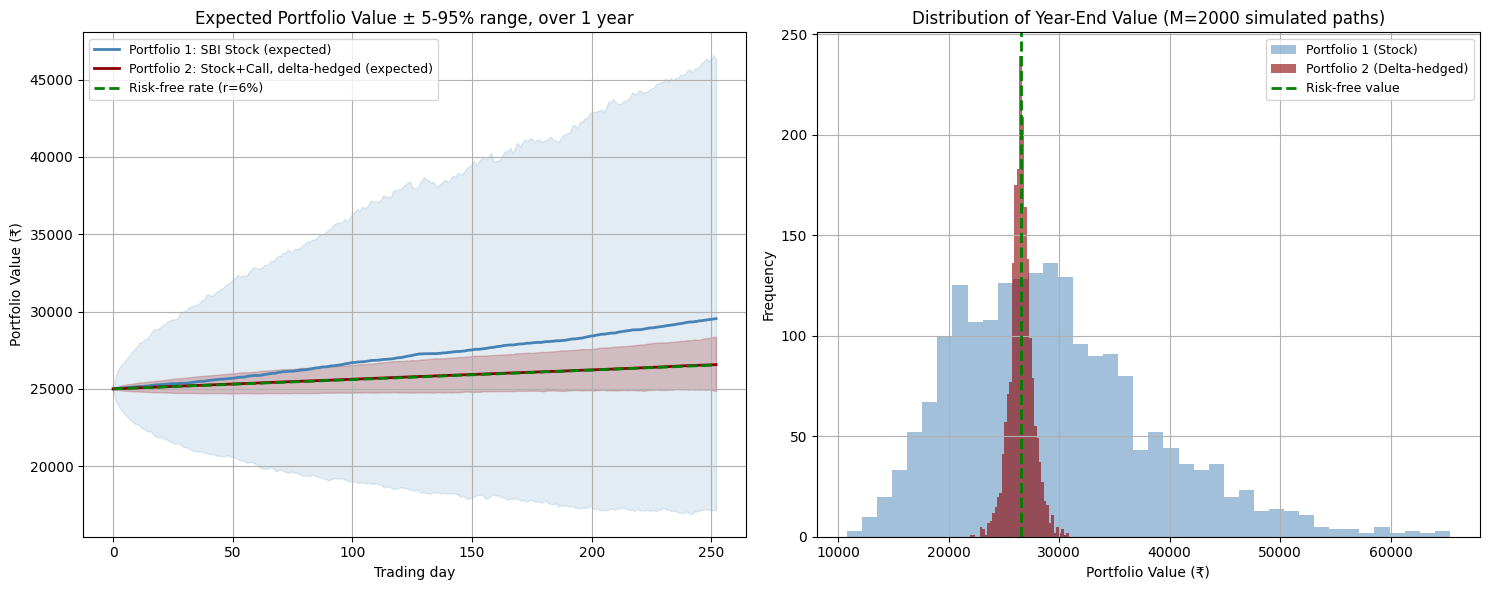

Summary - Portfolio 1 vs Portfolio 2 vs Risk-Free, after 1 year:


,Expected final value (₹),Expected return,Std Dev of final value (₹)
Portfolio 1 (Stock),29541.3681,0.1817,8975.1484
Portfolio 2 (Delta-hedged),26567.5645,0.0627,1068.6283
Risk-free,26545.9137,0.0618,0.0000


In [31]:
# ---- expected value, risk band, and final distribution ----
days = np.arange(N_days + 1)
rf_curve = INITIAL_CAPITAL * np.exp(r * days * dt)

exp_1, exp_2 = value_1.mean(axis=0), value_2.mean(axis=0)
lo_1, hi_1 = np.percentile(value_1, 5, axis=0), np.percentile(value_1, 95, axis=0)
lo_2, hi_2 = np.percentile(value_2, 5, axis=0), np.percentile(value_2, 95, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].fill_between(days, lo_1, hi_1, color="steelblue", alpha=0.15)
axes[0].fill_between(days, lo_2, hi_2, color="darkred", alpha=0.20)
axes[0].plot(days, exp_1, color="steelblue", lw=2, label="Portfolio 1: SBI Stock (expected)")
axes[0].plot(days, exp_2, color="darkred", lw=2, label="Portfolio 2: Stock+Call, delta-hedged (expected)")
axes[0].plot(days, rf_curve, color="green", lw=2, ls="--", label=f"Risk-free rate (r={r:.0%})")
axes[0].set_title("Expected Portfolio Value ± 5-95% range, over 1 year")
axes[0].set_xlabel("Trading day"); axes[0].set_ylabel("Portfolio Value (₹)")
axes[0].legend(fontsize=9); axes[0].grid(True)

axes[1].hist(value_1[:, -1], bins=40, alpha=0.5, color="steelblue", label="Portfolio 1 (Stock)")
axes[1].hist(value_2[:, -1], bins=40, alpha=0.6, color="darkred", label="Portfolio 2 (Delta-hedged)")
axes[1].axvline(rf_curve[-1], color="green", lw=2, ls="--", label="Risk-free value")
axes[1].set_title(f"Distribution of Year-End Value (M={M_paths} simulated paths)")
axes[1].set_xlabel("Portfolio Value (₹)"); axes[1].set_ylabel("Frequency")
axes[1].legend(fontsize=9); axes[1].grid(True)

plt.tight_layout()
plt.show()

summary = pd.DataFrame({
    "Expected final value (₹)": [exp_1[-1], exp_2[-1], rf_curve[-1]],
    "Expected return":              [exp_1[-1]/INITIAL_CAPITAL - 1, exp_2[-1]/INITIAL_CAPITAL - 1, rf_curve[-1]/INITIAL_CAPITAL - 1],
    "Std Dev of final value (₹)": [value_1[:, -1].std(), value_2[:, -1].std(), 0.0],
}, index=["Portfolio 1 (Stock)", "Portfolio 2 (Delta-hedged)", "Risk-free"])

print("Summary - Portfolio 1 vs Portfolio 2 vs Risk-Free, after 1 year:")
summary.round(4)


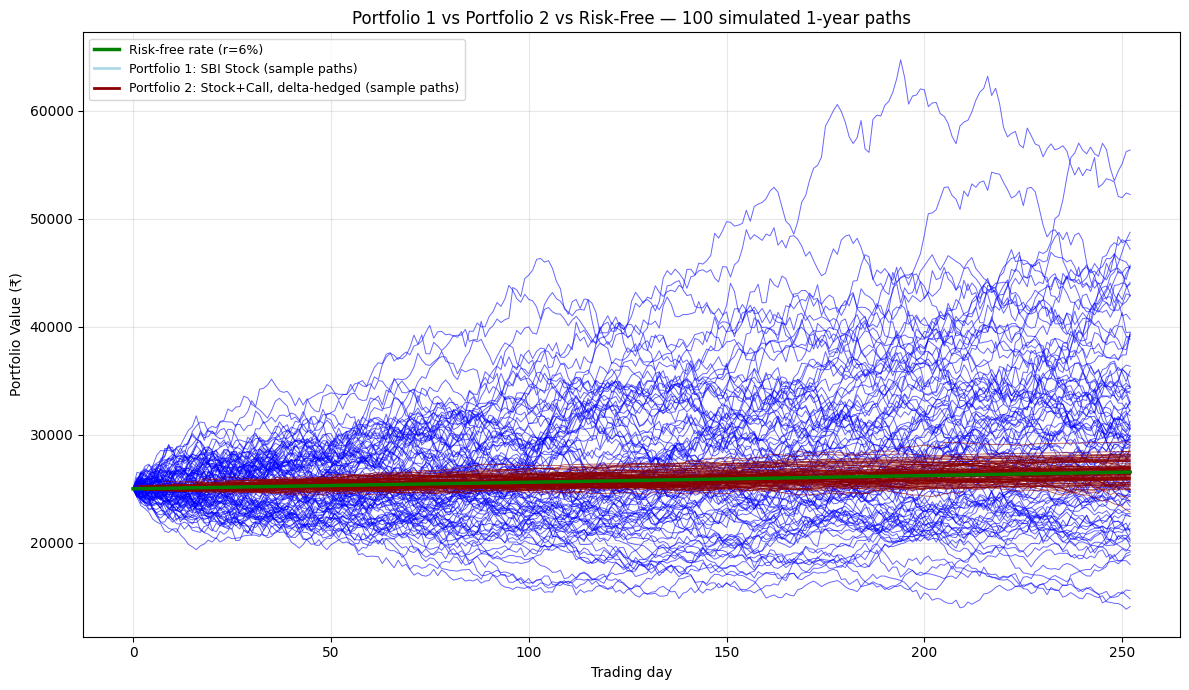

In [32]:
# ---- plot individual simulated paths instead of percentile bands ----
n_sample_paths = 100                       # how many of the M_paths simulations to draw
rng = np.random.default_rng(7)
sample_idx = rng.choice(M_paths, size=n_sample_paths, replace=False)

plt.figure(figsize=(12, 7))

for i in sample_idx:
    plt.plot(days, value_1[i], color="blue", linewidth=0.7, alpha=0.6)
for i in sample_idx:
    plt.plot(days, value_2[i], color="darkred", linewidth=0.7, alpha=0.6)

plt.plot(days, rf_curve, color="green", linewidth=2.5, label=f"Risk-free rate (r={r:.0%})")

# dummy plots just to get clean legend entries (real lines above have no label)
plt.plot([], [], color="lightblue", linewidth=2, label="Portfolio 1: SBI Stock (sample paths)")
plt.plot([], [], color="darkred", linewidth=2, label="Portfolio 2: Stock+Call, delta-hedged (sample paths)")

plt.title(f"Portfolio 1 vs Portfolio 2 vs Risk-Free \u2014 {n_sample_paths} simulated 1-year paths")
plt.xlabel("Trading day")
plt.ylabel("Portfolio Value (\u20b9)")
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

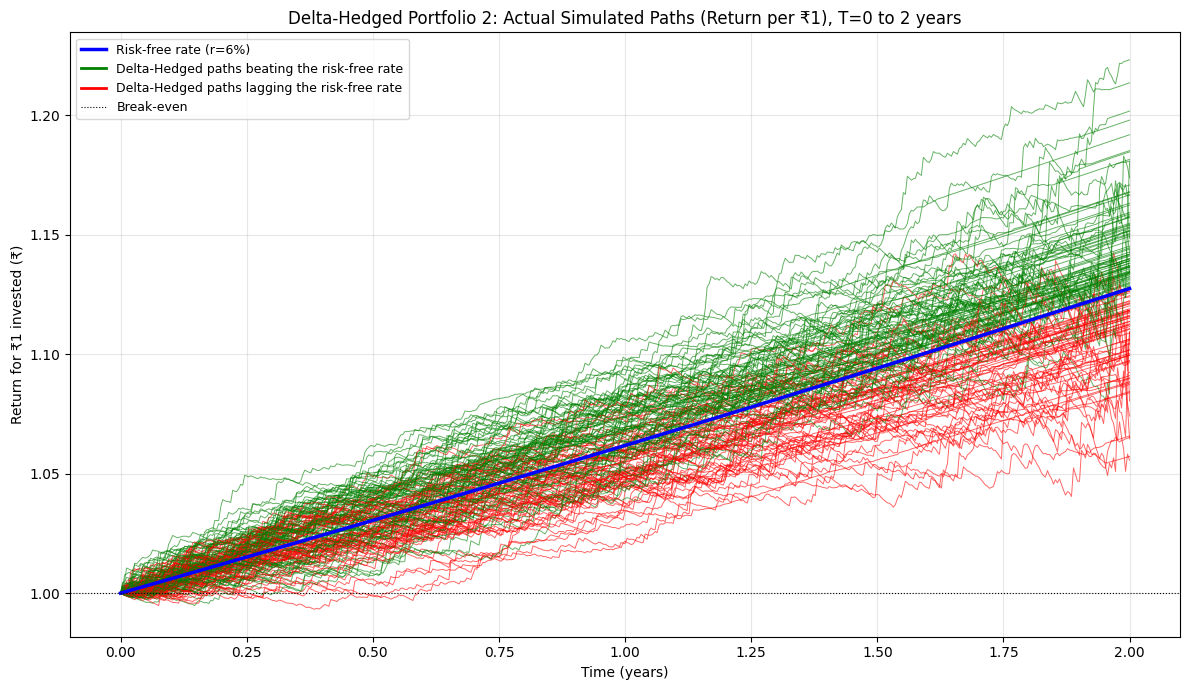

In [33]:
# ---- Task 7 (extension): actual simulated paths of the delta-hedged portfolio over time, random seed each run ----
np.random.seed(None)          # no fixed seed -> results change every time this cell is run

T_horizon = 2.0                # years - the paths run from t=0 out to this horizon
N_horizon = int(round(T_horizon * 252))
M_paths_paths = 150            # number of individual paths to simulate & draw
K_h = S0                        # at-the-money call, struck at today's SBI price

S_sim_h = simulate_gbm_paths(S0, mu_val, sigma_val, T_horizon, N_horizon, M_paths_paths)

C0_h = bs_call_price(S0, K_h, T_horizon, r, sigma_val)
delta0_h = bs_call_delta(S0, K_h, T_horizon, r, sigma_val)
Q_h = INITIAL_CAPITAL / C0_h

h = np.full(M_paths_paths, -Q_h * delta0_h)                                    # short stock leg
cash = np.full(M_paths_paths, INITIAL_CAPITAL - Q_h * C0_h + Q_h * delta0_h * S0)
dt_h = T_horizon / N_horizon

value_path = np.zeros((M_paths_paths, N_horizon + 1))
value_path[:, 0] = Q_h * C0_h + h * S0 + cash                                   # = INITIAL_CAPITAL

for t in range(1, N_horizon + 1):
    cash *= np.exp(r * dt_h)
    S_t = S_sim_h[:, t]
    tau = T_horizon - t * dt_h
    if t < N_horizon:
        delta_t = bs_call_delta(S_t, K_h, tau, r, sigma_val)
        h_new = -Q_h * delta_t
        cash -= (h_new - h) * S_t
        h = h_new
        price_t = bs_call_price(S_t, K_h, tau, r, sigma_val)
    else:
        price_t = np.maximum(S_t - K_h, 0.0)               # option expires, settle at intrinsic value
    value_path[:, t] = Q_h * price_t + h * S_t + cash

per_rupee_paths = value_path / INITIAL_CAPITAL              # return for ₹1 invested, at every point in time
time_axis = np.linspace(0, T_horizon, N_horizon + 1)
risk_free_curve_h = np.exp(r * time_axis)

plt.figure(figsize=(12, 7))
for i in range(M_paths_paths):
    color = "green" if per_rupee_paths[i, -1] >= risk_free_curve_h[-1] else "red"   # vs. the risk-free line, not break-even
    plt.plot(time_axis, per_rupee_paths[i], color=color, lw=0.7, alpha=0.6)

plt.plot(time_axis, risk_free_curve_h, color="blue", lw=2.5, label=f"Risk-free rate (r={r:.0%})")
plt.plot([], [], color="green", lw=2, label="Delta-Hedged paths beating the risk-free rate")
plt.plot([], [], color="red", lw=2, label="Delta-Hedged paths lagging the risk-free rate")
plt.axhline(1.0, color="black", lw=0.8, linestyle=":", label="Break-even")

plt.title(f"Delta-Hedged Portfolio 2: Actual Simulated Paths (Return per \u20b91), T=0 to {T_horizon:.0f} years")
plt.xlabel("Time (years)")
plt.ylabel("Return for \u20b91 invested (\u20b9)")
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Task 8 - Excess Return over the Risk-Free Rate, Across Different Maturities

Repeats the Task 7 comparison (Portfolio 1: buy-and-hold SBI stock vs. Portfolio 2: delta-hedged stock+call, both funded with the same `INITIAL_CAPITAL`) across a whole range of maturities T = 0.1, 0.2, ..., 3.0 years instead of just the single T = 1 year used in Task 7, and plots each portfolio's **excess return over the risk-free rate** (expected return above what the same capital would have earned just sitting in the risk-free asset) as a function of maturity.

In [34]:
# Task 8 - repeat the Task 7 setup across a range of maturities T, and compute
# each portfolio's EXCESS RETURN over the risk-free rate at each T
T_values = np.round(np.arange(0.1, 3.01, 0.1), 2)   # 0.1, 0.2, ..., 3.0 years
M_paths_T8 = 1000   # fewer paths than Task 7's M_paths since this reruns the whole sim per T

excess_return_1 = []   # Portfolio 1 (stock) excess return over risk-free, per T
excess_return_2 = []   # Portfolio 2 (delta-hedged) excess return over risk-free, per T

for T in T_values:
    N_days_T = max(1, int(round(T * 252)))
    dt_T = T / N_days_T

    # Simulate SBI over this maturity (real-world drift, same as Task 7)
    S_sim_T = simulate_gbm_paths(S0, mu_val, sigma_val, T, N_days_T, M_paths_T8, seed=42)

    # Portfolio 1 : buy-and-hold stock
    shares_1_T = INITIAL_CAPITAL / S0
    value_1_T_final = shares_1_T * S_sim_T[:, -1]

    # Portfolio 2 : long Q calls, short delta*Q shares, rebalanced daily (same mechanics as Task 7)
    K_T = S0   # at-the-money, same convention as Task 7
    C0_T = bs_call_price(S0, K_T, T, r, sigma_val)
    delta0_T = bs_call_delta(S0, K_T, T, r, sigma_val)
    Q_T = INITIAL_CAPITAL / C0_T

    h_T = np.full(M_paths_T8, -Q_T * delta0_T)
    cash_T = np.full(M_paths_T8, INITIAL_CAPITAL - Q_T * C0_T + Q_T * delta0_T * S0)
    value_2_T_final = None

    for t in range(1, N_days_T + 1):
        cash_T *= np.exp(r * dt_T)
        S_t = S_sim_T[:, t]
        tau = T - t * dt_T

        if t < N_days_T:
            delta_t = bs_call_delta(S_t, K_T, tau, r, sigma_val)
            h_new = -Q_T * delta_t
            cash_T -= (h_new - h_T) * S_t
            h_T = h_new
            price_t = bs_call_price(S_t, K_T, tau, r, sigma_val)
        else:
            price_t = np.maximum(S_t - K_T, 0.0)   # option expires, settle at intrinsic value

        value_2_T_final = Q_T * price_t + h_T * S_t + cash_T

    # expected (mean-across-paths) return for each portfolio at this maturity
    exp_return_1_T = value_1_T_final.mean() / INITIAL_CAPITAL - 1
    exp_return_2_T = value_2_T_final.mean() / INITIAL_CAPITAL - 1
    rf_return_T = np.exp(r * T) - 1                       # risk-free return over the same T

    # excess return = portfolio's expected return minus the risk-free return over the same period
    excess_return_1.append(exp_return_1_T - rf_return_T)
    excess_return_2.append(exp_return_2_T - rf_return_T)

excess_return_1 = np.array(excess_return_1)
excess_return_2 = np.array(excess_return_2)

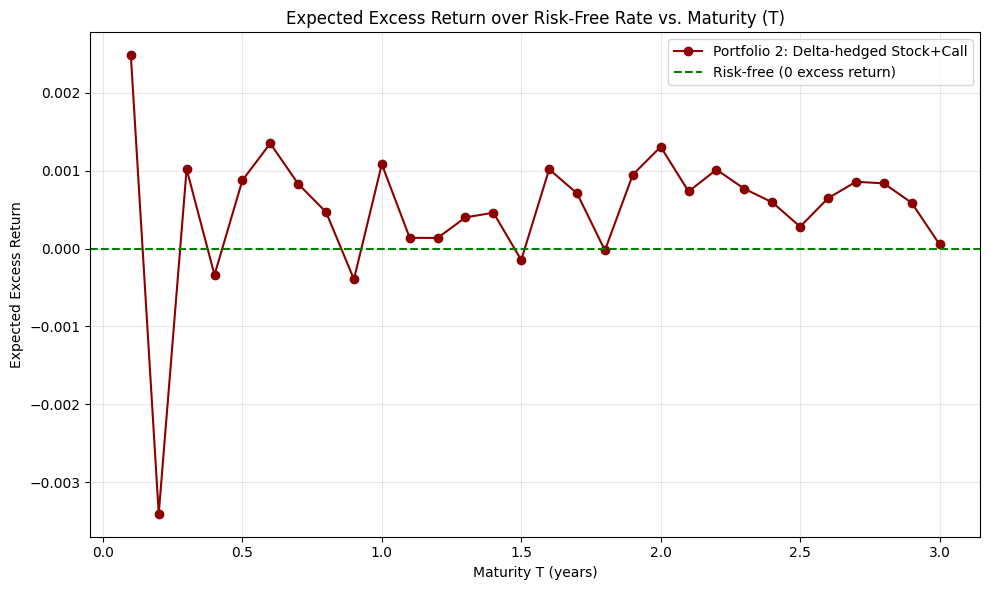

In [35]:
# Task 8 - plot excess return over the risk-free rate vs. maturity
plt.figure(figsize=(10, 6))
plt.plot(T_values, excess_return_2, marker='o', color='darkred', label='Portfolio 2: Delta-hedged Stock+Call')
plt.axhline(0, color='green', linestyle='--', lw=1.5, label='Risk-free (0 excess return)')
plt.title('Expected Excess Return over Risk-Free Rate vs. Maturity (T)')
plt.xlabel('Maturity T (years)')
plt.ylabel('Expected Excess Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [36]:
print(f"Delta-hedged strategy achieves {exp_2[-1]/INITIAL_CAPITAL*100 - 100:.2f}% return, assuming risk-free is {r*100:.1f}% over a {N_days/252:.0f}-year horizon.")

Delta-hedged strategy achieves 6.27% return, assuming risk-free is 6.0% over a 1-year horizon.


In [37]:
# -------------------------------------------------------------
# Terminal Performance Evaluation (Rupees & Return %)
# -------------------------------------------------------------

# 1. Theoretical Risk-Free Benchmark Terminal Value
rf_final_val = INITIAL_CAPITAL * np.exp(r * 1.0)
rf_return_pct = (rf_final_val - INITIAL_CAPITAL) / INITIAL_CAPITAL * 100

# 2. Empirical Monte Carlo Delta-Hedged Portfolio Terminal Value
# Extract terminal value across all M_paths on day N_days
value_2_final = value_2[:, -1]
delta_hedged_final_val = np.mean(value_2_final)
delta_hedged_return_pct = (delta_hedged_final_val - INITIAL_CAPITAL) / INITIAL_CAPITAL * 100

# 3. Output Comparison
print("==================================================")
print("       PER ₹1 INVESTED PERFORMANCE SUMMARY        ")
print("==================================================")
print(f"Risk-Free Target Rate  : {r*100:.2f}%")
print(f"Risk-Free Benchmark    : ₹1.0000 ➔ ₹{rf_final_val:.4f} ({rf_return_pct:.2f}%)")
print(f"Simulated Delta-Hedge  : ₹1.0000 ➔ ₹{delta_hedged_final_val:.4f} ({delta_hedged_return_pct:.2f}%)")
print("--------------------------------------------------")
print(f"Tracking Variance      : ₹{abs(delta_hedged_final_val - rf_final_val):.6f} per ₹1")
print("==================================================")

       PER ₹1 INVESTED PERFORMANCE SUMMARY        
Risk-Free Target Rate  : 6.00%
Risk-Free Benchmark    : ₹1.0000 ➔ ₹26545.9137 (6.18%)
Simulated Delta-Hedge  : ₹1.0000 ➔ ₹26567.5645 (6.27%)
--------------------------------------------------
Tracking Variance      : ₹21.650828 per ₹1
